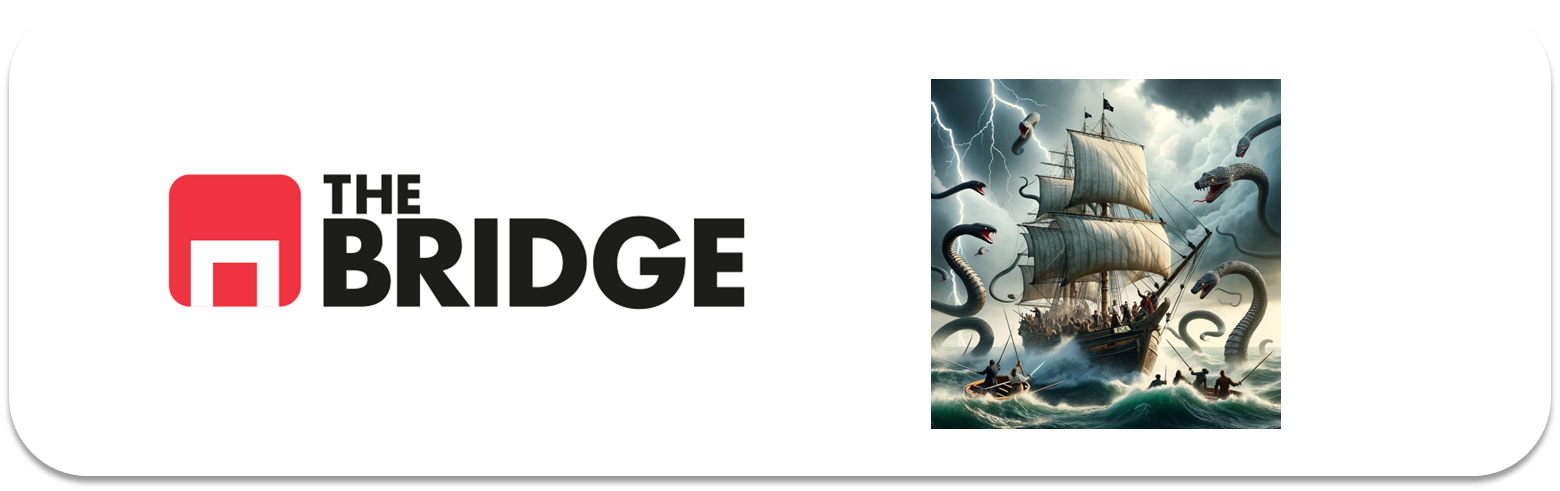

# PRÁCTICA OBLIGATORIA
## **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso.

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia.

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [354]:
from collections import Counter
from matplotlib import ticker
from scipy import stats
from sklearn.feature_selection import chi2, f_classif, SelectFromModel, \
									  SelectKBest, SequentialFeatureSelector, \
									  RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, mutual_info_score
from sklearn.model_selection import cross_validate, KFold, train_test_split, \
									RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [204]:
plt.style.use("petroff10")

In [205]:
def get_quality(dataframe: pd.DataFrame) -> pd.DataFrame:
	if dataframe is None:
		raise ValueError("Dataframe sin especificar.")

	if not isinstance(dataframe, pd.DataFrame):
		raise ValueError("El dataframe debe ser pd.DataFrame")

	records = dataframe.shape[0]

	unique = dataframe.nunique().rename("Cardinality")
	cardinality = (unique/records).rename("Uniqueness")
	null = (dataframe.isna().sum()).rename("Null")

	data = pd.DataFrame(data=[unique, cardinality, null])

	return data.T

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificación sobre la variable `SeriousDlqin2yrs` del dataset que encontrarás en `./data`.

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el **MiniEDA** aplica los siguientes análisis y selección de features:
	1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
	2. Selección de features numéricas mediante **SelectKBest** y **ANOVA**, selección de features categóricas mediante **Mutual Information**.
	3. Selección de las mejores features a través de un modelo intermedio (usando **SelectFromModel**).
	4. Selección de las mejores features empleando **RFE** *recursive feature elimination*.
	5. Selección de las mejores features empleando **SFS** *sequential feature selection*.
	6. Selección de las mejores features mediante un sistema de *hard-voting* aplicado a lo obtenido en los pasos 1 a 5 anteriores.

	Para cada paso anterior (salvo el 1) se pide obtener una lista de features de *primera división* con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.

In [206]:
df_credit = pd.read_csv("./data/credit_npo.csv")
df_credit.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [207]:
df_credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [208]:
get_quality(df_credit)

,Cardinality,Uniqueness,Null
SeriousDlqin2yrs,2.0,0.000160,0.0
RevolvingUtilizationOfUnsecuredLines,10764.0,0.858579,0.0
age,78.0,0.006222,0.0
NumberOfTime30-59DaysPastDueNotWorse,10.0,0.000798,0.0
DebtRatio,11547.0,0.921034,0.0
MonthlyIncome,4167.0,0.332376,721.0
NumberOfOpenCreditLinesAndLoans,43.0,0.003430,0.0
NumberOfTimes90DaysLate,13.0,0.001037,0.0
NumberRealEstateLoansOrLines,16.0,0.001276,0.0
NumberOfTime60-89DaysPastDueNotWorse,8.0,0.000638,0.0


In [209]:
df_credit.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,12537.0,0.068916,0.253321,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,12537.0,0.330359,0.368148,0.0,0.030651,0.163490,0.582219,6.0
age,12537.0,52.079445,15.077498,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,12537.0,0.409588,4.055787,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,12537.0,1.902253,9.122216,0.0,0.142268,0.302025,0.506725,99.0
MonthlyIncome,11816.0,6864.815420,11855.905437,0.0,3498.750000,5416.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,12537.0,8.482332,5.165422,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,12537.0,0.259312,4.035658,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,12537.0,0.999202,1.134325,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,12537.0,0.228364,4.018873,0.0,0.000000,0.000000,0.000000,98.0


Eliminamos los nulos

In [210]:
df_credit.dropna(inplace=True)
df_credit.info()

<class 'pandas.DataFrame'>
Index: 11816 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      11816 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  11816 non-null  float64
 2   age                                   11816 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  11816 non-null  int64  
 4   DebtRatio                             11816 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       11816 non-null  int64  
 7   NumberOfTimes90DaysLate               11816 non-null  int64  
 8   NumberRealEstateLoansOrLines          11816 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  11816 non-null  int64  
 10  NumberOfDependents                    11816 non-null  float64
dtypes: float64(4), int64(7)
memory 

Train-Test split

In [211]:
features = df_credit.drop(columns=["SeriousDlqin2yrs"]).columns
target = "SeriousDlqin2yrs"

In [212]:
df_train, df_test = train_test_split(
	df_credit,
	test_size=.2,
	shuffle=True,
	stratify=df_credit[target],
	random_state=42
)

MiniEDA

In [213]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.style"] = "normal"

# FIGURE
plt.rcParams["figure.constrained_layout.use"] = True
plt.rcParams["figure.titlesize"] = "xx-large"
plt.rcParams["figure.titleweight"] = "black"

# AXES
plt.rcParams["axes.labelcolor"] = "#1F2937"
plt.rcParams["axes.labelpad"] = 10
plt.rcParams["axes.labelsize"] = "medium"
plt.rcParams["axes.labelweight"] = 300
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.titlecolor"] = "#1E3A8A"
plt.rcParams["axes.titlesize"] = "large"
plt.rcParams["axes.titlepad"] = 5
plt.rcParams["axes.titleweight"] = "heavy"

# GRID
plt.rcParams["grid.color"] = "#D4D4D4"
plt.rcParams["grid.linestyle"] = "dotted"
plt.rcParams["grid.linewidth"] = 1

# TICKS
plt.rcParams["xtick.major.width"] = 0
#plt.rcParams["xtick.minor.width"] = 0
plt.rcParams["ytick.major.width"] = 0
#plt.rcParams["ytick.minor.width"] = 0

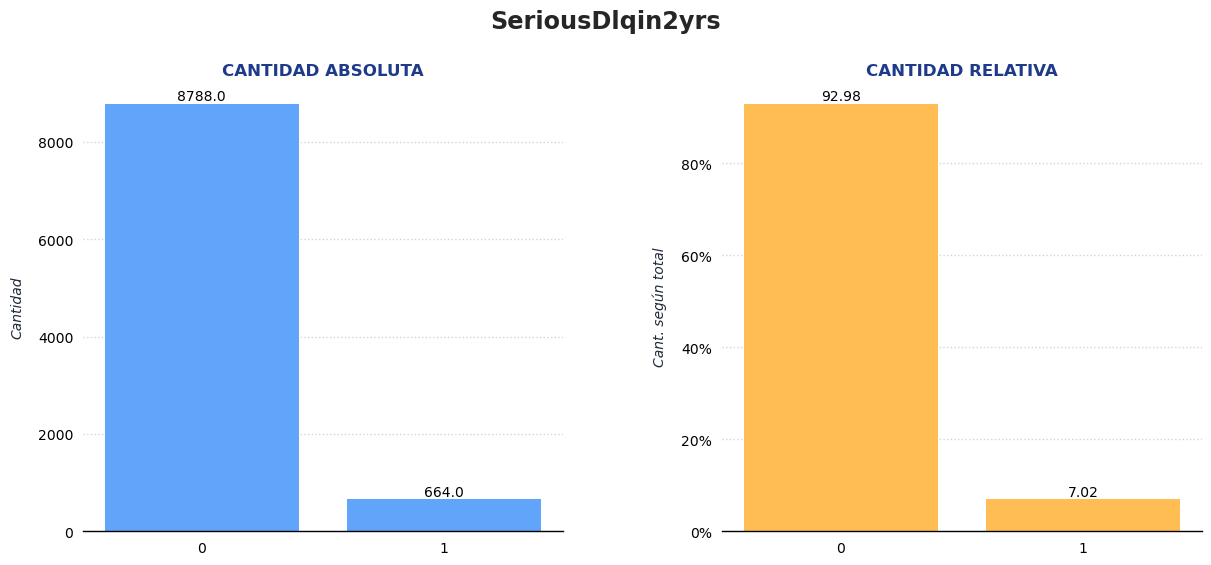

In [214]:
serie = df_train["SeriousDlqin2yrs"]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
fig.suptitle(f"{serie.name}", color="#262626", y=1.1)
axs[0].set_title("Cantidad absoluta".upper())

data = serie.value_counts()
bar_container = axs[0].bar(
	x=data.index,
	height=data.values,
	data=data,
	color="#60A5FA",
	zorder=2
)
axs[0].bar_label(bar_container, fmt=lambda x: f"{x:.1f}")

axs[0].set_xticks(ticks=data.index)
axs[0].set_ylabel("Cantidad", fontstyle="italic")
axs[0].grid(axis="y")
axs[0].spines[["left"]].set_visible(False)
axs[0].spines["bottom"].set_linewidth(1)



axs[1].set_title("Cantidad relativa".upper())
data = serie.value_counts(normalize=True)
rect = axs[1].bar(
	x=data.index,
	height=data.values,
	data=data,
	color="#FFBD54",
	zorder=2
)
axs[1].bar_label(rect, fmt=lambda x: f"{x * 100:.2f}")

axs[1].set_xticks(ticks=data.index)
axs[1].set_ylabel("Cant. según total", fontstyle="italic")
axs[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axs[1].grid(axis="y")
axs[1].spines[["left"]].set_visible(False)
axs[1].spines["bottom"].set_linewidth(1)

fig.get_layout_engine().set(wspace=0.15)
plt.show()

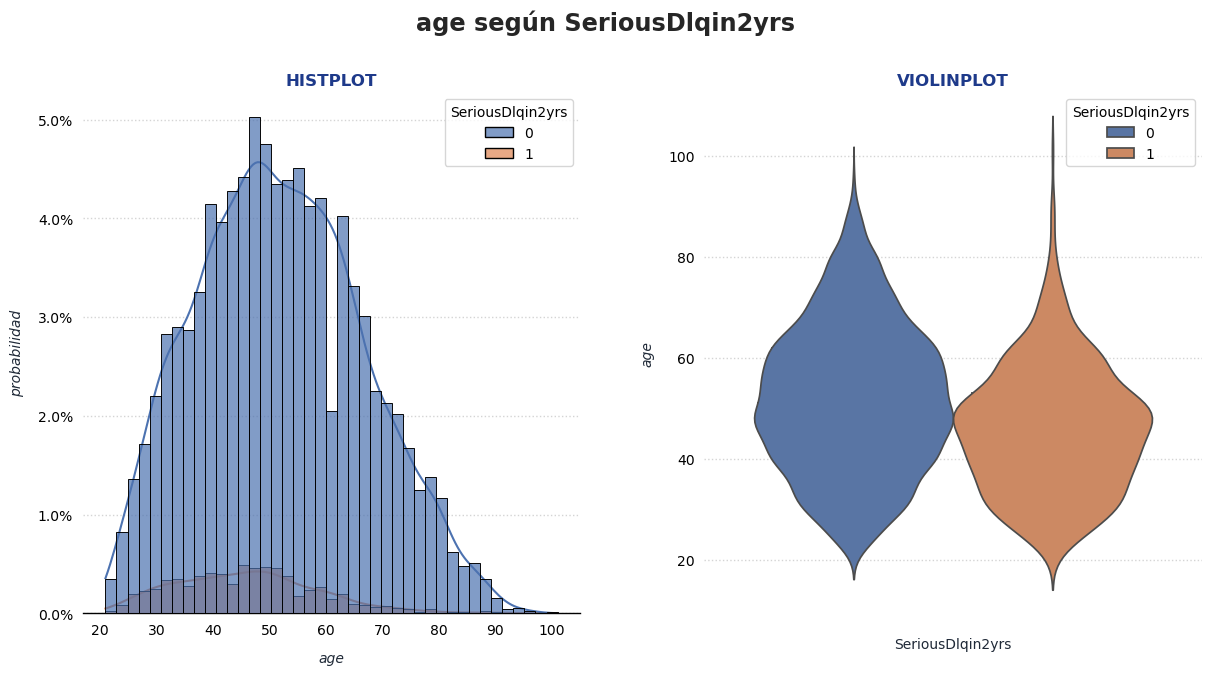

In [215]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
fig.suptitle("age según SeriousDlqin2yrs", color="#262626", y=1.1)

axs[0].set_title("Histplot".upper())
sns.histplot(
	data=df_train,
	x="age",
	hue="SeriousDlqin2yrs",
	bins="fd",
	kde=True,
	stat="probability",
	alpha=.7,
	palette="deep",
	zorder=9,
	ax=axs[0]
)
sns.despine(ax=axs[0])
axs[0].yaxis.set_major_formatter(ticker.PercentFormatter(1))

axs[0].set_xlabel("age", fontstyle="italic")
axs[0].set_ylabel("probabilidad", fontstyle="italic")
axs[0].grid(axis="y")
axs[0].spines[["left"]].set_visible(False)
axs[0].spines["bottom"].set_linewidth(1)



axs[1].set_title("Violinplot".upper())
sns.violinplot(
	data=df_train,
	y="age",
	inner="quart",
	hue="SeriousDlqin2yrs",
	palette="deep",
	zorder=9,
	ax=axs[1]
)

sns.despine(ax=axs[1])
axs[1].set_xlabel("SeriousDlqin2yrs")
axs[1].set_ylabel("age", fontstyle="italic")
axs[1].grid(axis="y")
axs[1].spines[["left", "bottom"]].set_visible(False)
axs[1].spines["bottom"].set_linewidth(1)

fig.get_layout_engine().set(wspace=.1)
plt.show()

In [216]:
def filter_outliers(
	serie: pd.Series,
	whisker: float | None=1.75,
	below_zero=False
) -> pd.Series:
	q25 = serie.quantile(.25)
	q75 = serie.quantile(.75)
	iqr = q75 - q25

	minimum = q25 - whisker * iqr
	maximum = q75 + whisker * iqr

	if minimum < 0:
		minimum = minimum if below_zero else 0

	below_minimum = serie > minimum
	above_maximum = serie < maximum
	mask = below_minimum & above_maximum

	return serie[mask]

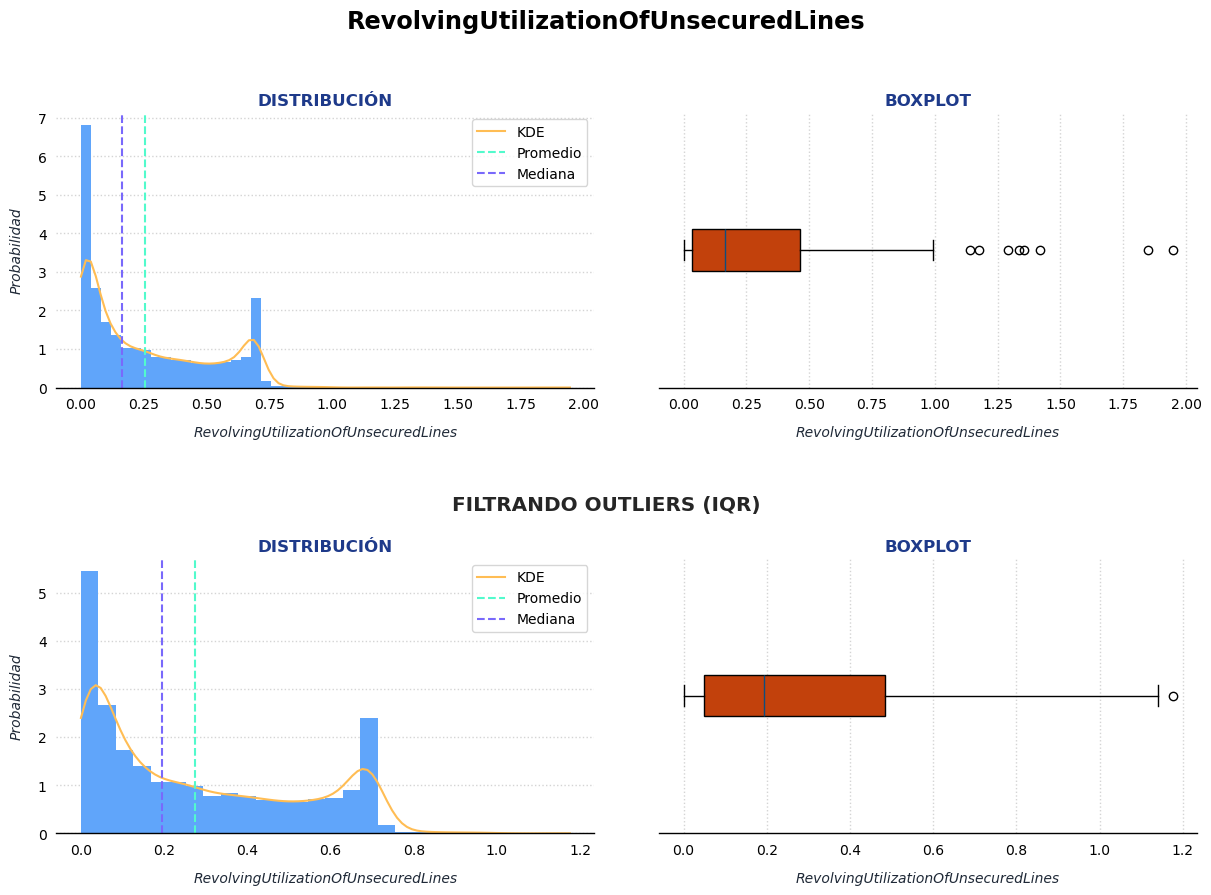

In [217]:
serie = np.log1p(df_train["RevolvingUtilizationOfUnsecuredLines"])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle("RevolvingUtilizationOfUnsecuredLines", y=1.1)

axs[0][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(serie, bins="fd")
axs[0][0].hist(x=serie, bins=bins, density=True, color="#60A5FA", zorder=2)

x = np.linspace(serie.min(), serie.max(), 100)
kde = stats.gaussian_kde(serie)
axs[0][0].plot(x, kde(x), color="#FFBD54", label="KDE")

# PROMEDIO
axs[0][0].axvline(
	serie.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
# MEDIANA
axs[0][0].axvline(
	serie.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[0][0].set_xlabel("RevolvingUtilizationOfUnsecuredLines", fontstyle="italic")
axs[0][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[0][0].grid(axis="y")
axs[0][0].spines[["left"]].set_visible(False)
axs[0][0].spines["bottom"].set_linewidth(1)
axs[0][0].legend()




axs[0][1].set_title("Boxplot".upper())
axs[0][1].boxplot(
	x=serie,
	boxprops={"facecolor" : "#C2410C"},
	medianprops={"color" : "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[0][1].set_yticks([])
axs[0][1].set_xlabel("RevolvingUtilizationOfUnsecuredLines", fontstyle="italic")
axs[0][1].set_ylabel("")
axs[0][1].grid(axis="x")
axs[0][1].spines[["left"]].set_visible(False)
axs[0][1].spines["bottom"].set_linewidth(1)




font_config = {
	"family": "sans-serif",
	"size": "x-large",
	"weight": "black"
}
fig.text(
	0.5, 0.48,
	"FILTRANDO OUTLIERS (IQR)",
	color="#262626",
	va="center",
	ha="center",
	fontdict=font_config
)

data = filter_outliers(serie, below_zero=False)
axs[1][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(data, bins="fd")
axs[1][0].hist(x=data, bins=bins, density=True, color="#60A5FA", zorder=2)
x = np.linspace(data.min(), data.max(), 100)
kde = stats.gaussian_kde(data)
axs[1][0].plot(x, kde(x), color="#FFBD54", label="KDE")

axs[1][0].axvline(
	data.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
axs[1][0].axvline(
	data.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[1][0].set_xlabel("RevolvingUtilizationOfUnsecuredLines", fontstyle="italic")
axs[1][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[1][0].grid(axis="y")
axs[1][0].spines[["left"]].set_visible(False)
axs[1][0].spines["bottom"].set_linewidth(1)
axs[1][0].legend()




axs[1][1].set_title("Boxplot".upper())
axs[1][1].boxplot(
	x=data,
	boxprops={ "facecolor" : "#C2410C" },
	medianprops={ "color" : "#0F4D7D" },
	orientation="horizontal",
	patch_artist=True
)

axs[1][1].set_yticks([])
axs[1][1].set_xlabel("RevolvingUtilizationOfUnsecuredLines", fontstyle="italic")
axs[1][1].set_ylabel("")
axs[1][1].grid(axis="x")
axs[1][1].spines[["left"]].set_visible(False)
axs[1][1].spines["bottom"].set_linewidth(1)


fig.get_layout_engine().set(hspace=.25, wspace=.1)
plt.show()

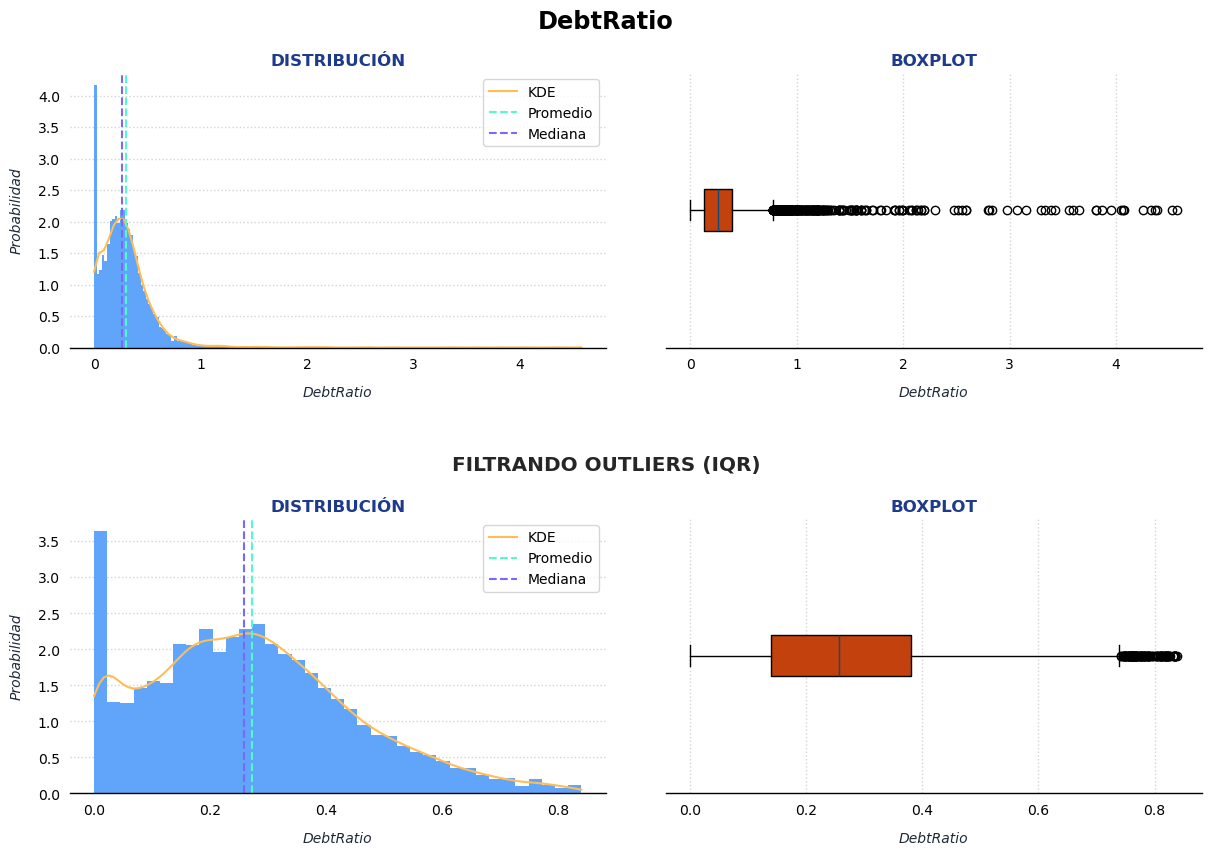

In [218]:
serie = np.log1p(df_train["DebtRatio"])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle("DebtRatio", y=1.05)

axs[0][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(serie, bins="fd")
axs[0][0].hist(x=serie, bins=bins, density=True, color="#60A5FA", zorder=2)

x = np.linspace(serie.min(), serie.max(), 100)
kde = stats.gaussian_kde(serie)
axs[0][0].plot(x, kde(x), color="#FFBD54", label="KDE")

# PROMEDIO
axs[0][0].axvline(
	serie.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
# MEDIANA
axs[0][0].axvline(
	serie.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[0][0].set_xlabel("DebtRatio", fontstyle="italic")
axs[0][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[0][0].grid(axis="y")
axs[0][0].spines[["left"]].set_visible(False)
axs[0][0].spines["bottom"].set_linewidth(1)
axs[0][0].legend()




axs[0][1].set_title("Boxplot".upper())
axs[0][1].boxplot(
	x=serie,
	boxprops={"facecolor" : "#C2410C"},
	medianprops={"color" : "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[0][1].set_yticks([])
axs[0][1].set_xlabel("DebtRatio", fontstyle="italic")
axs[0][1].set_ylabel("")
axs[0][1].grid(axis="x")
axs[0][1].spines[["left"]].set_visible(False)
axs[0][1].spines["bottom"].set_linewidth(1)




font_config = {
	"family": "sans-serif",
	"size": "x-large",
	"weight": "black"
}
fig.text(
	0.5, 0.48,
	"FILTRANDO OUTLIERS (IQR)",
	color="#262626",
	va="center",
	ha="center",
	fontdict=font_config
)

data = filter_outliers(serie, below_zero=False)
axs[1][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(data, bins="fd")
axs[1][0].hist(x=data, bins=bins, density=True, color="#60A5FA", zorder=2)
x = np.linspace(data.min(), data.max(), 100)
kde = stats.gaussian_kde(data)
axs[1][0].plot(x, kde(x), color="#FFBD54", label="KDE")

axs[1][0].axvline(
	data.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
axs[1][0].axvline(
	data.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[1][0].set_xlabel("DebtRatio", fontstyle="italic")
axs[1][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[1][0].grid(axis="y")
axs[1][0].spines[["left"]].set_visible(False)
axs[1][0].spines["bottom"].set_linewidth(1)
axs[1][0].legend()




axs[1][1].set_title("Boxplot".upper())
axs[1][1].boxplot(
	x=data,
	boxprops={"facecolor": "#C2410C"},
	medianprops={"color": "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[1][1].set_yticks([])
axs[1][1].set_xlabel("DebtRatio", fontstyle="italic")
axs[1][1].set_ylabel("")
axs[1][1].grid(axis="x")
axs[1][1].spines[["left"]].set_visible(False)
axs[1][1].spines["bottom"].set_linewidth(1)


fig.get_layout_engine().set(hspace=0.25, wspace=0.1)
plt.show()

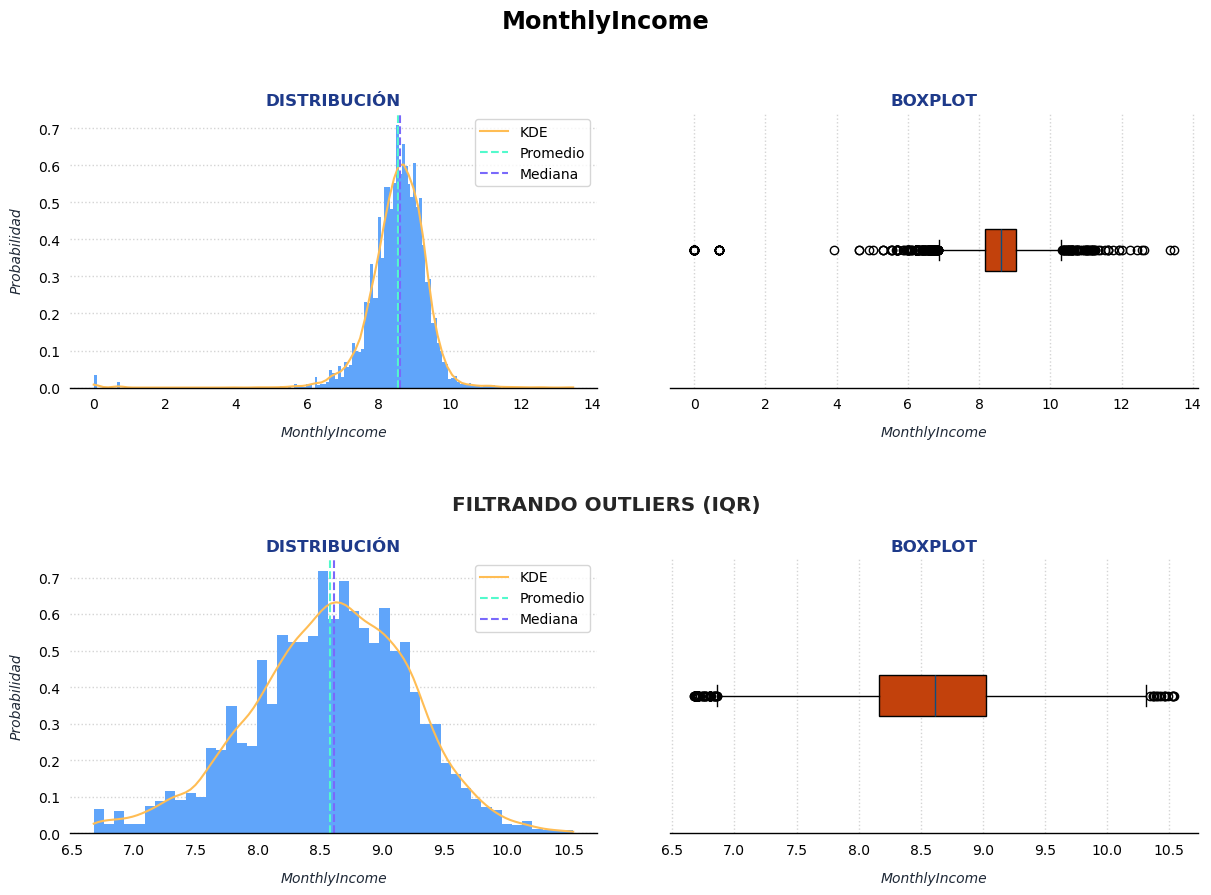

In [219]:
serie = np.log1p(df_train["MonthlyIncome"])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle("MonthlyIncome", y=1.1)

axs[0][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(serie, bins="fd")
axs[0][0].hist(x=serie, bins=bins, density=True, color="#60A5FA", zorder=2)

x = np.linspace(serie.min(), serie.max(), 100)
kde = stats.gaussian_kde(serie)
axs[0][0].plot(x, kde(x), color="#FFBD54", label="KDE")

# PROMEDIO
axs[0][0].axvline(
	serie.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
# MEDIANA
axs[0][0].axvline(
	serie.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[0][0].set_xlabel("MonthlyIncome", fontstyle="italic")
axs[0][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[0][0].grid(axis="y")
axs[0][0].spines[["left"]].set_visible(False)
axs[0][0].spines["bottom"].set_linewidth(1)
axs[0][0].legend()




axs[0][1].set_title("Boxplot".upper())
axs[0][1].boxplot(
	x=serie,
	boxprops={"facecolor" : "#C2410C"},
	medianprops={"color" : "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[0][1].set_yticks([])
axs[0][1].set_xlabel("MonthlyIncome", fontstyle="italic")
axs[0][1].set_ylabel("")
axs[0][1].grid(axis="x")
axs[0][1].spines[["left"]].set_visible(False)
axs[0][1].spines["bottom"].set_linewidth(1)




font_config = {
	"family": "sans-serif",
	"size": "x-large",
	"weight": "black"
}
fig.text(
	0.5, 0.48,
	"FILTRANDO OUTLIERS (IQR)",
	color="#262626",
	va="center",
	ha="center",
	fontdict=font_config
)

data = filter_outliers(serie, below_zero=False)
axs[1][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(data, bins="fd")
axs[1][0].hist(x=data, bins=bins, density=True, color="#60A5FA", zorder=2)
x = np.linspace(data.min(), data.max(), 100)
kde = stats.gaussian_kde(data)
axs[1][0].plot(x, kde(x), color="#FFBD54", label="KDE")

axs[1][0].axvline(
	data.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
axs[1][0].axvline(
	data.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[1][0].set_xlabel("MonthlyIncome", fontstyle="italic")
axs[1][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[1][0].grid(axis="y")
axs[1][0].spines[["left"]].set_visible(False)
axs[1][0].spines["bottom"].set_linewidth(1)
axs[1][0].legend()



axs[1][1].set_title("Boxplot".upper())
axs[1][1].boxplot(
	x=data,
	boxprops={"facecolor": "#C2410C"},
	medianprops={"color": "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[1][1].set_yticks([])
axs[1][1].set_xlabel("MonthlyIncome", fontstyle="italic")
axs[1][1].set_ylabel("")
axs[1][1].grid(axis="x")
axs[1][1].spines[["left"]].set_visible(False)
axs[1][1].spines["bottom"].set_linewidth(1)

fig.get_layout_engine().set(hspace=0.25, wspace=0.1)
plt.show()

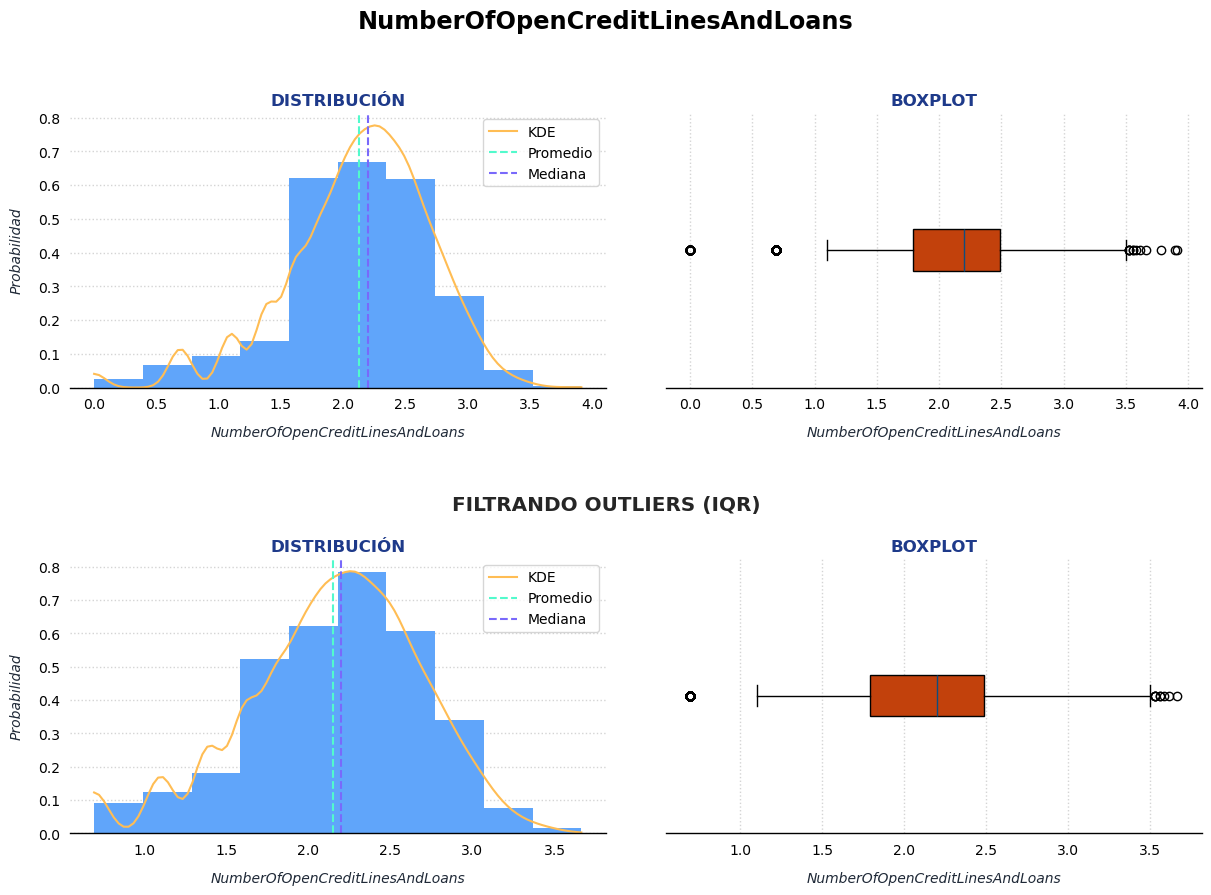

In [220]:
serie = np.log1p(df_train["NumberOfOpenCreditLinesAndLoans"])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle("NumberOfOpenCreditLinesAndLoans", y=1.1)

axs[0][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(serie, bins="fd")
axs[0][0].hist(x=serie,  density=True, color="#60A5FA", zorder=2)

x = np.linspace(serie.min(), serie.max(), 100)
kde = stats.gaussian_kde(serie)
axs[0][0].plot(x, kde(x), color="#FFBD54", label="KDE")

# PROMEDIO
axs[0][0].axvline(
	serie.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
# MEDIANA
axs[0][0].axvline(
	serie.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[0][0].set_xlabel("NumberOfOpenCreditLinesAndLoans", fontstyle="italic")
axs[0][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[0][0].grid(axis="y")
axs[0][0].spines[["left"]].set_visible(False)
axs[0][0].spines["bottom"].set_linewidth(1)
axs[0][0].legend()




axs[0][1].set_title("Boxplot".upper())
axs[0][1].boxplot(
	x=serie,
	boxprops={"facecolor" : "#C2410C"},
	medianprops={"color" : "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[0][1].set_yticks([])
axs[0][1].set_xlabel("NumberOfOpenCreditLinesAndLoans", fontstyle="italic")
axs[0][1].set_ylabel("")
axs[0][1].grid(axis="x")
axs[0][1].spines[["left"]].set_visible(False)
axs[0][1].spines["bottom"].set_linewidth(1)




font_config = {
	"family": "sans-serif",
	"size": "x-large",
	"weight": "black"
}
fig.text(
	0.5, 0.48,
	"FILTRANDO OUTLIERS (IQR)",
	color="#262626",
	va="center",
	ha="center",
	fontdict=font_config
)

data = filter_outliers(serie, below_zero=False)
axs[1][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(data, bins="fd")
axs[1][0].hist(x=data, density=True, color="#60A5FA", zorder=2)
x = np.linspace(data.min(), data.max(), 100)
kde = stats.gaussian_kde(data)
axs[1][0].plot(x, kde(x), color="#FFBD54", label="KDE")

axs[1][0].axvline(
	data.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
axs[1][0].axvline(
	data.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[1][0].set_xlabel("NumberOfOpenCreditLinesAndLoans", fontstyle="italic")
axs[1][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[1][0].grid(axis="y")
axs[1][0].spines[["left"]].set_visible(False)
axs[1][0].spines["bottom"].set_linewidth(1)
axs[1][0].legend()



axs[1][1].set_title("Boxplot".upper())
axs[1][1].boxplot(
	x=data,
	boxprops={"facecolor": "#C2410C"},
	medianprops={"color": "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[1][1].set_yticks([])
axs[1][1].set_xlabel("NumberOfOpenCreditLinesAndLoans", fontstyle="italic")
axs[1][1].set_ylabel("")
axs[1][1].grid(axis="x")
axs[1][1].spines[["left"]].set_visible(False)
axs[1][1].spines["bottom"].set_linewidth(1)

fig.get_layout_engine().set(hspace=0.25, wspace=0.1)
plt.show()

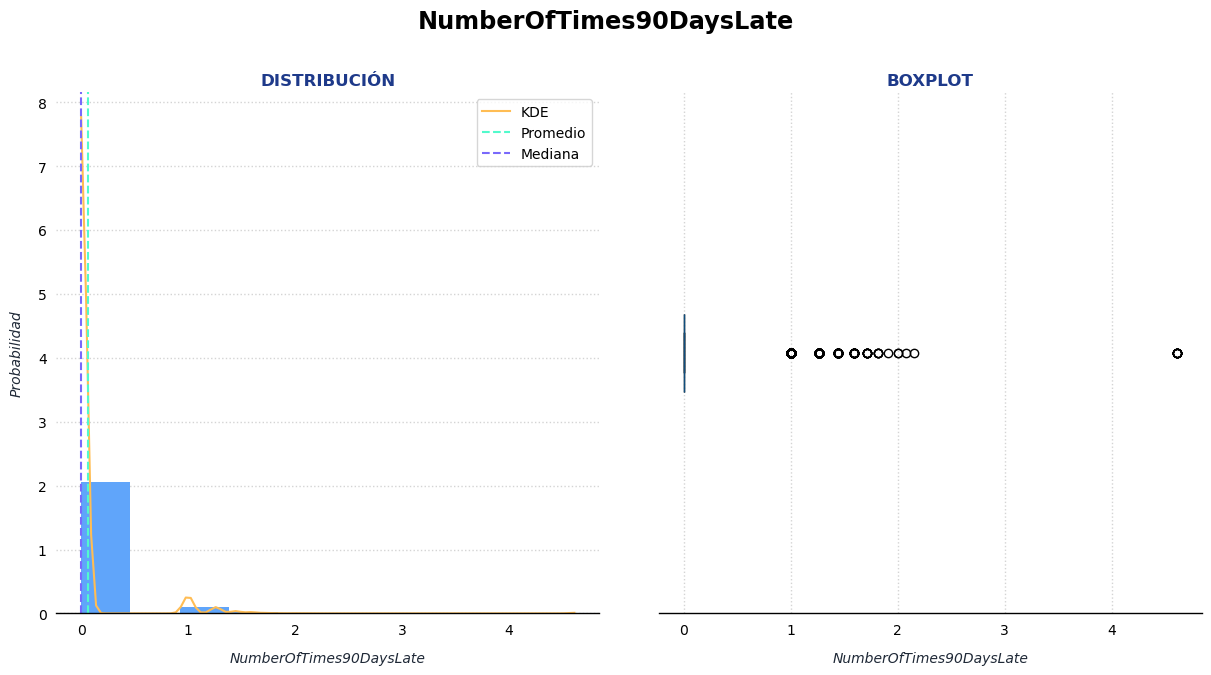

In [221]:
serie = np.cbrt(df_train["NumberOfTimes90DaysLate"])

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
fig.suptitle("NumberOfTimes90DaysLate", y=1.1)

axs[0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(serie, bins="fd")
axs[0].hist(x=serie, density=True, color="#60A5FA", zorder=2)

x = np.linspace(serie.min(), serie.max(), 100)
kde = stats.gaussian_kde(serie)
axs[0].plot(x, kde(x), color="#FFBD54", label="KDE")

# PROMEDIO
axs[0].axvline(
	serie.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
# MEDIANA
axs[0].axvline(
	serie.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[0].set_xlabel("NumberOfTimes90DaysLate", fontstyle="italic")
axs[0].set_ylabel("Probabilidad", fontstyle="italic")
axs[0].grid(axis="y")
axs[0].spines[["left"]].set_visible(False)
axs[0].spines["bottom"].set_linewidth(1)
axs[0].legend()




axs[1].set_title("Boxplot".upper())
axs[1].boxplot(
	x=serie,
	boxprops={"facecolor" : "#C2410C"},
	medianprops={"color" : "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[1].set_yticks([])
axs[1].set_xlabel("NumberOfTimes90DaysLate", fontstyle="italic")
axs[1].set_ylabel("")
axs[1].grid(axis="x")
axs[1].spines[["left"]].set_visible(False)
axs[1].spines["bottom"].set_linewidth(1)


fig.get_layout_engine().set(hspace=0.25, wspace=0.1)
plt.show()

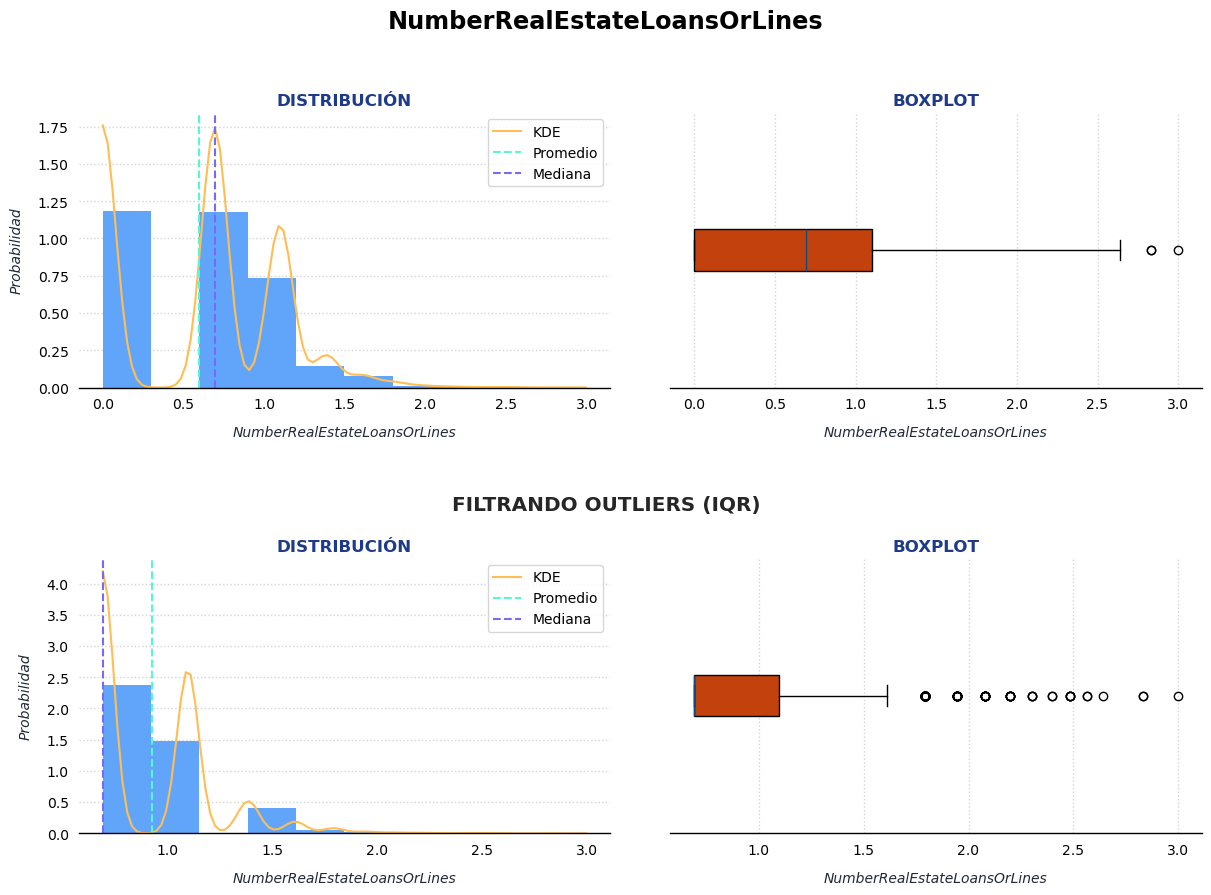

In [222]:
serie = np.log1p(df_train["NumberRealEstateLoansOrLines"])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle("NumberRealEstateLoansOrLines", y=1.1)

axs[0][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(serie, bins="fd")
axs[0][0].hist(x=serie, density=True, color="#60A5FA", zorder=2)

x = np.linspace(serie.min(), serie.max(), 100)
kde = stats.gaussian_kde(serie)
axs[0][0].plot(x, kde(x), color="#FFBD54", label="KDE")

# PROMEDIO
axs[0][0].axvline(
	serie.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
# MEDIANA
axs[0][0].axvline(
	serie.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[0][0].set_xlabel("NumberRealEstateLoansOrLines", fontstyle="italic")
axs[0][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[0][0].grid(axis="y")
axs[0][0].spines[["left"]].set_visible(False)
axs[0][0].spines["bottom"].set_linewidth(1)
axs[0][0].legend()




axs[0][1].set_title("Boxplot".upper())
axs[0][1].boxplot(
	x=serie,
	boxprops={"facecolor" : "#C2410C"},
	medianprops={"color" : "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[0][1].set_yticks([])
axs[0][1].set_xlabel("NumberRealEstateLoansOrLines", fontstyle="italic")
axs[0][1].set_ylabel("")
axs[0][1].grid(axis="x")
axs[0][1].spines[["left"]].set_visible(False)
axs[0][1].spines["bottom"].set_linewidth(1)




font_config = {
	"family": "sans-serif",
	"size": "x-large",
	"weight": "black"
}
fig.text(
	0.5, 0.48,
	"FILTRANDO OUTLIERS (IQR)",
	color="#262626",
	va="center",
	ha="center",
	fontdict=font_config
)

data = filter_outliers(serie, below_zero=False)
axs[1][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(data, bins="fd")
axs[1][0].hist(x=data, density=True, color="#60A5FA", zorder=2)
x = np.linspace(data.min(), data.max(), 100)
kde = stats.gaussian_kde(data)
axs[1][0].plot(x, kde(x), color="#FFBD54", label="KDE")

axs[1][0].axvline(
	data.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
axs[1][0].axvline(
	data.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[1][0].set_xlabel("NumberRealEstateLoansOrLines", fontstyle="italic")
axs[1][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[1][0].grid(axis="y")
axs[1][0].spines[["left"]].set_visible(False)
axs[1][0].spines["bottom"].set_linewidth(1)
axs[1][0].legend()



axs[1][1].set_title("Boxplot".upper())
axs[1][1].boxplot(
	x=data,
	boxprops={"facecolor": "#C2410C"},
	medianprops={"color": "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[1][1].set_yticks([])
axs[1][1].set_xlabel("NumberRealEstateLoansOrLines", fontstyle="italic")
axs[1][1].set_ylabel("")
axs[1][1].grid(axis="x")
axs[1][1].spines[["left"]].set_visible(False)
axs[1][1].spines["bottom"].set_linewidth(1)

fig.get_layout_engine().set(hspace=0.25, wspace=0.1)
plt.show()

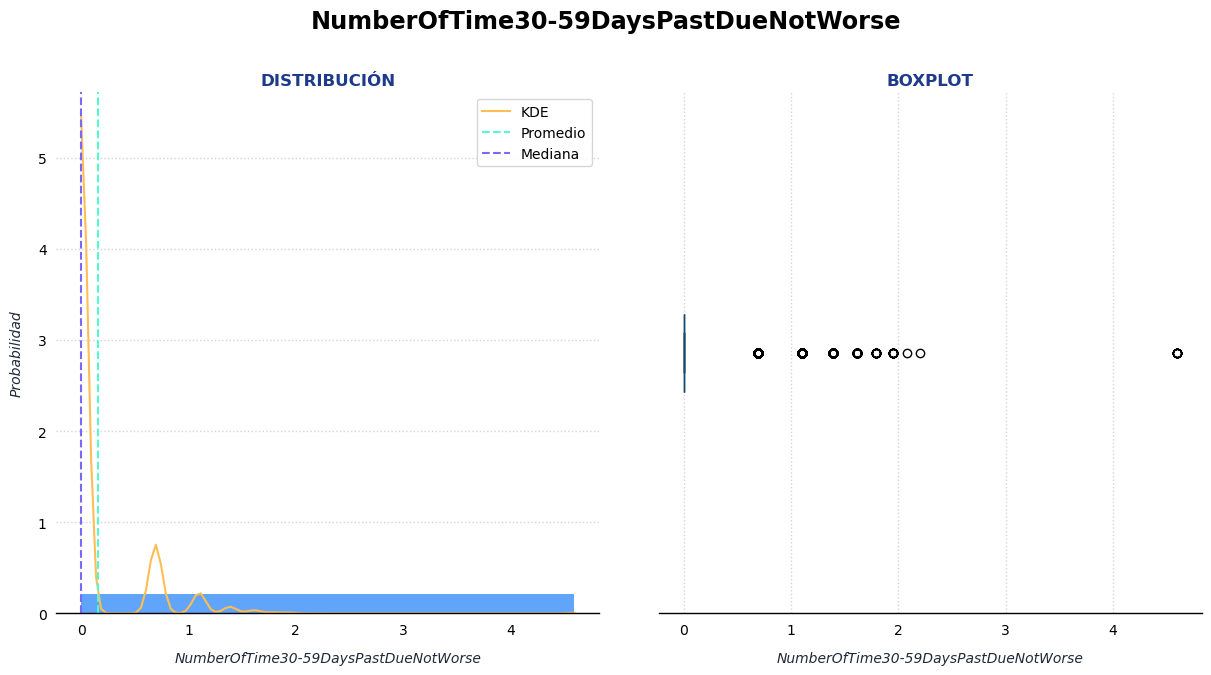

In [223]:
serie = np.log1p(df_train["NumberOfTime30-59DaysPastDueNotWorse"])

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
fig.suptitle("NumberOfTime30-59DaysPastDueNotWorse", y=1.1)

axs[0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(serie, bins="fd")
axs[0].hist(x=serie, bins=bins, density=True, color="#60A5FA", zorder=2)

x = np.linspace(serie.min(), serie.max(), 100)
kde = stats.gaussian_kde(serie)
axs[0].plot(x, kde(x), color="#FFBD54", label="KDE")

# PROMEDIO
axs[0].axvline(
	serie.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
# MEDIANA
axs[0].axvline(
	serie.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[0].set_xlabel("NumberOfTime30-59DaysPastDueNotWorse", fontstyle="italic")
axs[0].set_ylabel("Probabilidad", fontstyle="italic")
axs[0].grid(axis="y")
axs[0].spines[["left"]].set_visible(False)
axs[0].spines["bottom"].set_linewidth(1)
axs[0].legend()




axs[1].set_title("Boxplot".upper())
axs[1].boxplot(
	x=serie,
	boxprops={"facecolor" : "#C2410C"},
	medianprops={"color" : "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[1].set_yticks([])
axs[1].set_xlabel("NumberOfTime30-59DaysPastDueNotWorse", fontstyle="italic")
axs[1].set_ylabel("")
axs[1].grid(axis="x")
axs[1].spines[["left"]].set_visible(False)
axs[1].spines["bottom"].set_linewidth(1)

fig.get_layout_engine().set(hspace=0.25, wspace=0.1)
plt.show()

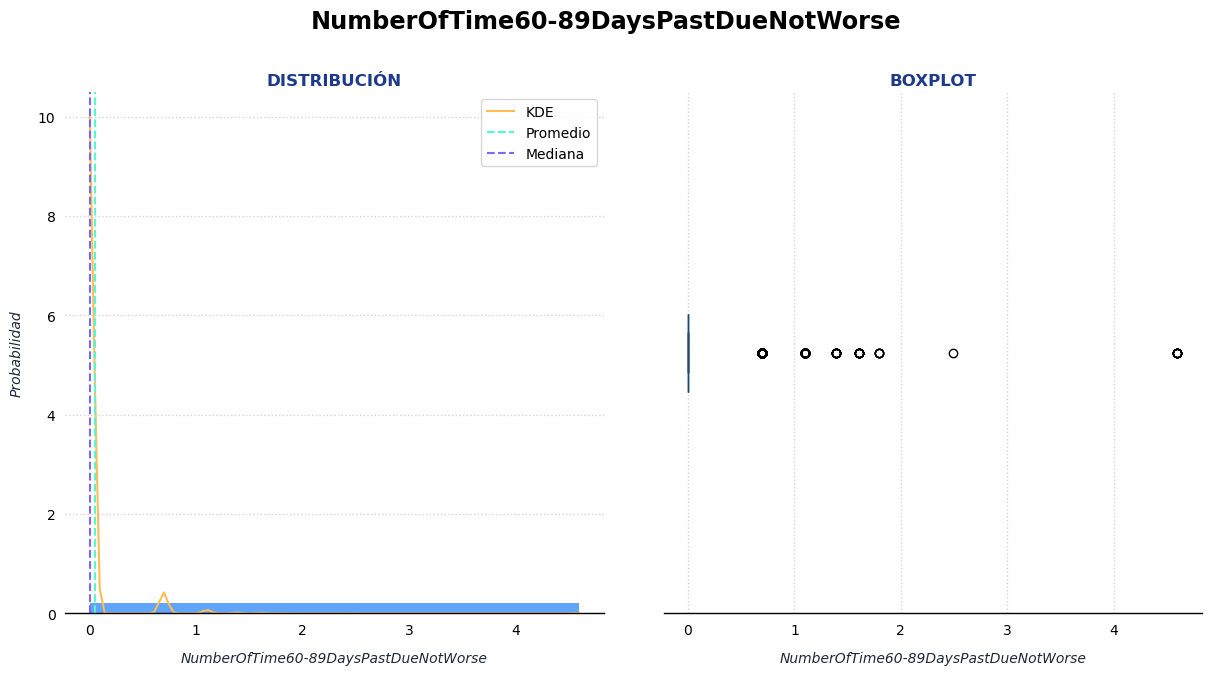

In [224]:
serie = np.log1p(df_train["NumberOfTime60-89DaysPastDueNotWorse"])

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
fig.suptitle("NumberOfTime60-89DaysPastDueNotWorse", y=1.1)

axs[0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(serie, bins="fd")
axs[0].hist(x=serie, bins=bins, density=True, color="#60A5FA", zorder=2)

x = np.linspace(serie.min(), serie.max(), 100)
kde = stats.gaussian_kde(serie)
axs[0].plot(x, kde(x), color="#FFBD54", label="KDE")

# PROMEDIO
axs[0].axvline(
	serie.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
# MEDIANA
axs[0].axvline(
	serie.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[0].set_xlabel("NumberOfTime60-89DaysPastDueNotWorse", fontstyle="italic")
axs[0].set_ylabel("Probabilidad", fontstyle="italic")
axs[0].grid(axis="y")
axs[0].spines[["left"]].set_visible(False)
axs[0].spines["bottom"].set_linewidth(1)
axs[0].legend()




axs[1].set_title("Boxplot".upper())
axs[1].boxplot(
	x=serie,
	boxprops={"facecolor" : "#C2410C"},
	medianprops={"color" : "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[1].set_yticks([])
axs[1].set_xlabel("NumberOfTime60-89DaysPastDueNotWorse", fontstyle="italic")
axs[1].set_ylabel("")
axs[1].grid(axis="x")
axs[1].spines[["left"]].set_visible(False)
axs[1].spines["bottom"].set_linewidth(1)

fig.get_layout_engine().set(hspace=0.25, wspace=0.1)
plt.show()

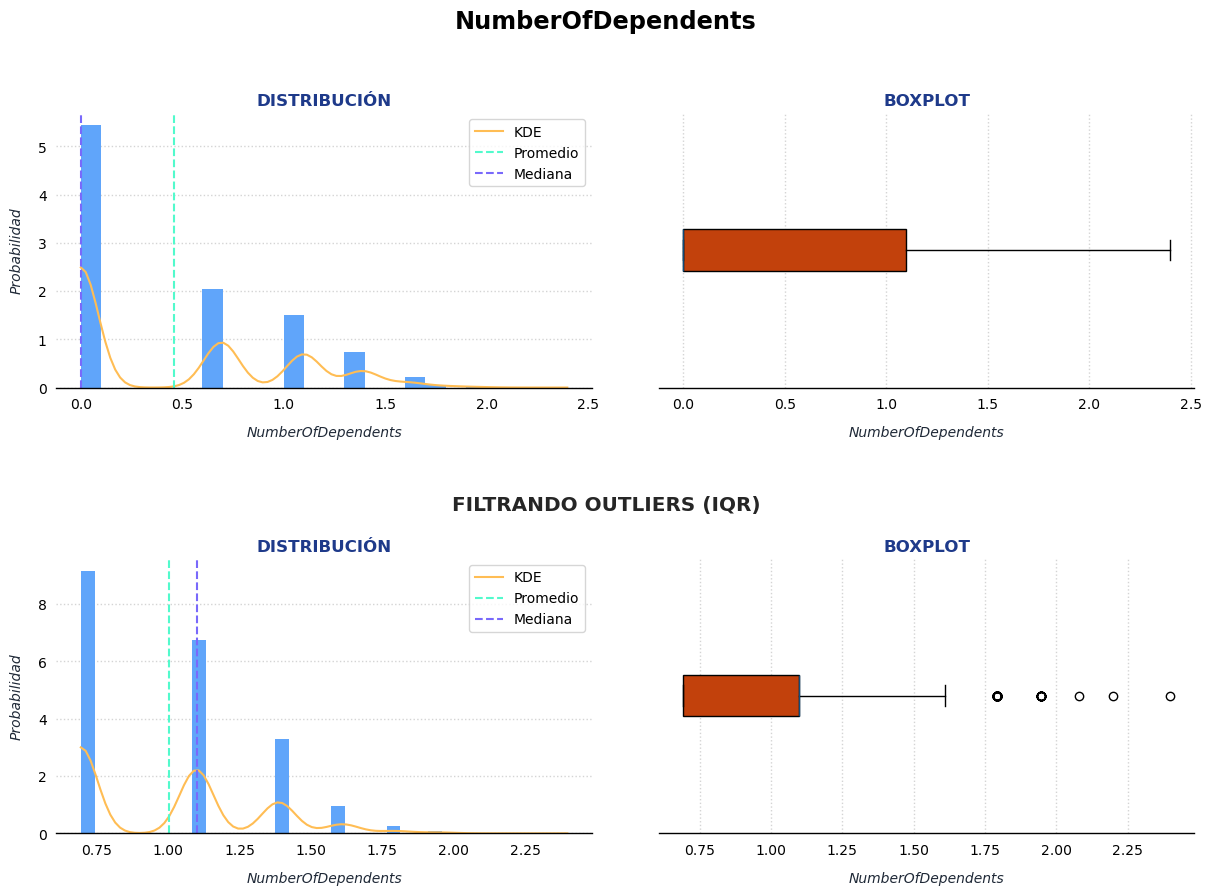

In [225]:
serie = np.log1p(df_train["NumberOfDependents"])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle("NumberOfDependents", y=1.1)

axs[0][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(serie, bins="fd")
axs[0][0].hist(x=serie, bins=bins, density=True, color="#60A5FA", zorder=2)

x = np.linspace(serie.min(), serie.max(), 100)
kde = stats.gaussian_kde(serie)
axs[0][0].plot(x, kde(x), color="#FFBD54", label="KDE")

# PROMEDIO
axs[0][0].axvline(
	serie.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
# MEDIANA
axs[0][0].axvline(
	serie.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[0][0].set_xlabel("NumberOfDependents", fontstyle="italic")
axs[0][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[0][0].grid(axis="y")
axs[0][0].spines[["left"]].set_visible(False)
axs[0][0].spines["bottom"].set_linewidth(1)
axs[0][0].legend()




axs[0][1].set_title("Boxplot".upper())
axs[0][1].boxplot(
	x=serie,
	boxprops={"facecolor" : "#C2410C"},
	medianprops={"color" : "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[0][1].set_yticks([])
axs[0][1].set_xlabel("NumberOfDependents", fontstyle="italic")
axs[0][1].set_ylabel("")
axs[0][1].grid(axis="x")
axs[0][1].spines[["left"]].set_visible(False)
axs[0][1].spines["bottom"].set_linewidth(1)



font_config = {
	"family": "sans-serif",
	"size": "x-large",
	"weight": "black"
}
fig.text(
	0.5, 0.48,
	"FILTRANDO OUTLIERS (IQR)",
	color="#262626",
	va="center",
	ha="center",
	fontdict=font_config
)

data = filter_outliers(serie, below_zero=False)
axs[1][0].set_title("Distribución".upper())

bins = np.histogram_bin_edges(data, bins="fd")
axs[1][0].hist(x=data, bins=bins, density=True, color="#60A5FA", zorder=2)
x = np.linspace(data.min(), data.max(), 100)
kde = stats.gaussian_kde(data)
axs[1][0].plot(x, kde(x), color="#FFBD54", label="KDE")

axs[1][0].axvline(
	data.mean(),
	linestyle="dashed",
	color="#52FACC",
	label="Promedio"
)
axs[1][0].axvline(
	data.median(),
	linestyle="dashed",
	color="#7969FB",
	label="Mediana"
)

axs[1][0].set_xlabel("NumberOfDependents", fontstyle="italic")
axs[1][0].set_ylabel("Probabilidad", fontstyle="italic")
axs[1][0].grid(axis="y")
axs[1][0].spines[["left"]].set_visible(False)
axs[1][0].spines["bottom"].set_linewidth(1)
axs[1][0].legend()



axs[1][1].set_title("Boxplot".upper())
axs[1][1].boxplot(
	x=data,
	boxprops={"facecolor": "#C2410C"},
	medianprops={"color": "#0F4D7D"},
	orientation="horizontal",
	patch_artist=True
)

axs[1][1].set_yticks([])
axs[1][1].set_xlabel("NumberOfDependents", fontstyle="italic")
axs[1][1].set_ylabel("")
axs[1][1].grid(axis="x")
axs[1][1].spines[["left"]].set_visible(False)
axs[1][1].spines["bottom"].set_linewidth(1)

fig.get_layout_engine().set(hspace=0.25, wspace=0.1)
plt.show()

Luego de analizar el dataset entendemos que:
| COLUMNA | CLASIFICACIÓN |
| -------: | :-------------: |
| age | Numérica discreta |
| NumberOfDependents | Numérica discreta |
| MonthlyIncome | Numérica continua |
| DebtRatio | Numérica continua |
| NumberOfTime30-59DaysPastDueNotWorse | Puede ser categorizable |
| NumberOfTime60-89DaysPastDueNotWorse | Puede ser categorizable |
| NumberOfTimes90DaysLate | Puede ser categorizable |
| NumberOfOpenCreditLinesAndLoans | Numérica discreta |
| NumberRealEstateLoansOrLines | Puede ser categorizable si controlamos los outliers |
| RevolvingUtilizationOfUnsecuredLines | Númerica continua |

In [226]:
get_quality(df_train)

,Cardinality,Uniqueness,Null
SeriousDlqin2yrs,2.0,0.000212,0.0
RevolvingUtilizationOfUnsecuredLines,8253.0,0.873149,0.0
age,78.0,0.008252,0.0
NumberOfTime30-59DaysPastDueNotWorse,10.0,0.001058,0.0
DebtRatio,9200.0,0.973339,0.0
MonthlyIncome,3559.0,0.376534,0.0
NumberOfOpenCreditLinesAndLoans,41.0,0.004338,0.0
NumberOfTimes90DaysLate,12.0,0.001270,0.0
NumberRealEstateLoansOrLines,16.0,0.001693,0.0
NumberOfTime60-89DaysPastDueNotWorse,8.0,0.000846,0.0


#### NumberRealEstateLoansOrLines

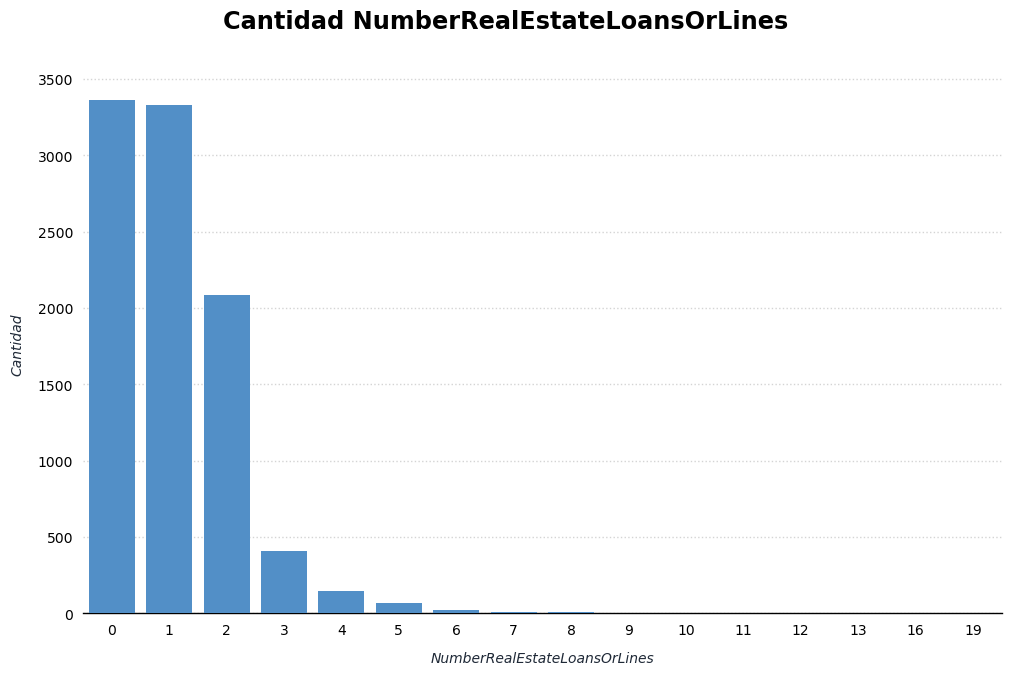

In [227]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Cantidad NumberRealEstateLoansOrLines", y=1.1)
sns.countplot(
	x="NumberRealEstateLoansOrLines",
	data=df_train,
	zorder=3,
	ax=ax
)
ax.set_xlabel("NumberRealEstateLoansOrLines", fontstyle="italic")
ax.set_ylabel("Cantidad", fontstyle="italic")
ax.grid(axis="y")
ax.spines[["left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
plt.show()

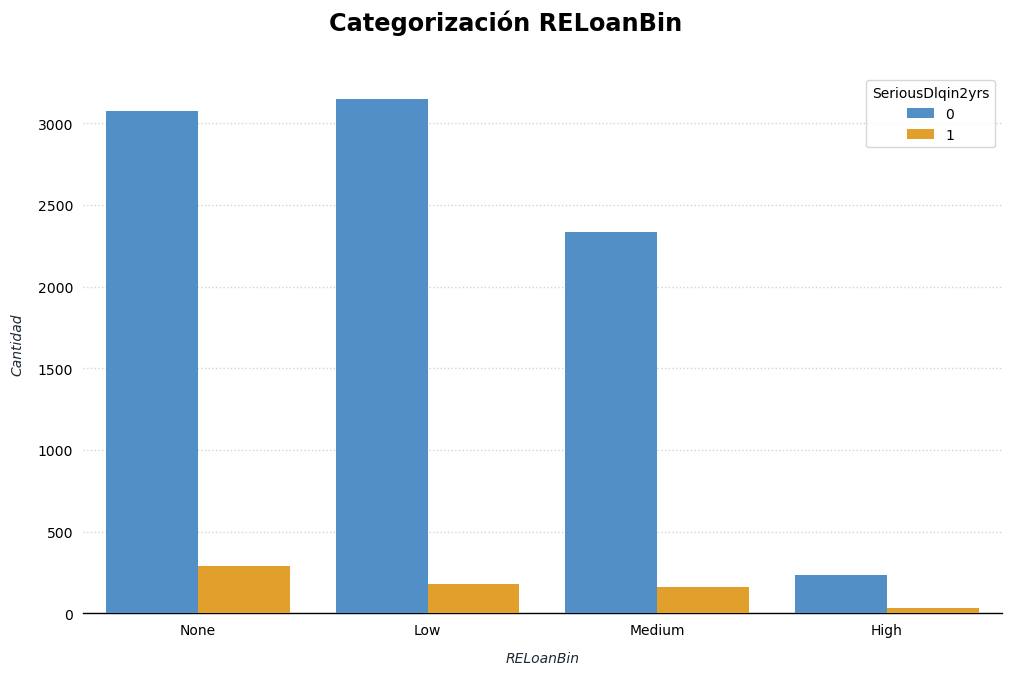

In [228]:
df_train["RELoanBin"] = pd.cut(
	x=df_train["NumberRealEstateLoansOrLines"],
	bins=[-np.inf, 0, 1, 3, np.inf],
	labels=["None", "Low", "Medium", "High"],
	include_lowest=True
)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Categorización RELoanBin", y=1.1)
sns.countplot(
	x="RELoanBin",
	data=df_train,
	hue=target,
	zorder=3,
	ax=ax
)
ax.set_xlabel("RELoanBin", fontstyle="italic")
ax.set_ylabel("Cantidad", fontstyle="italic")
ax.grid(axis="y")
ax.spines[["left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
plt.show()

In [229]:
df_test["RELoanBin"] = pd.cut(
	x=df_test["NumberRealEstateLoansOrLines"],
	bins=[-np.inf, 0, 1, 3, np.inf],
	labels=["None", "Low", "Medium", "High"],
	include_lowest=True
)

#### NumberOfTime30-59DaysPastDueNotWorse

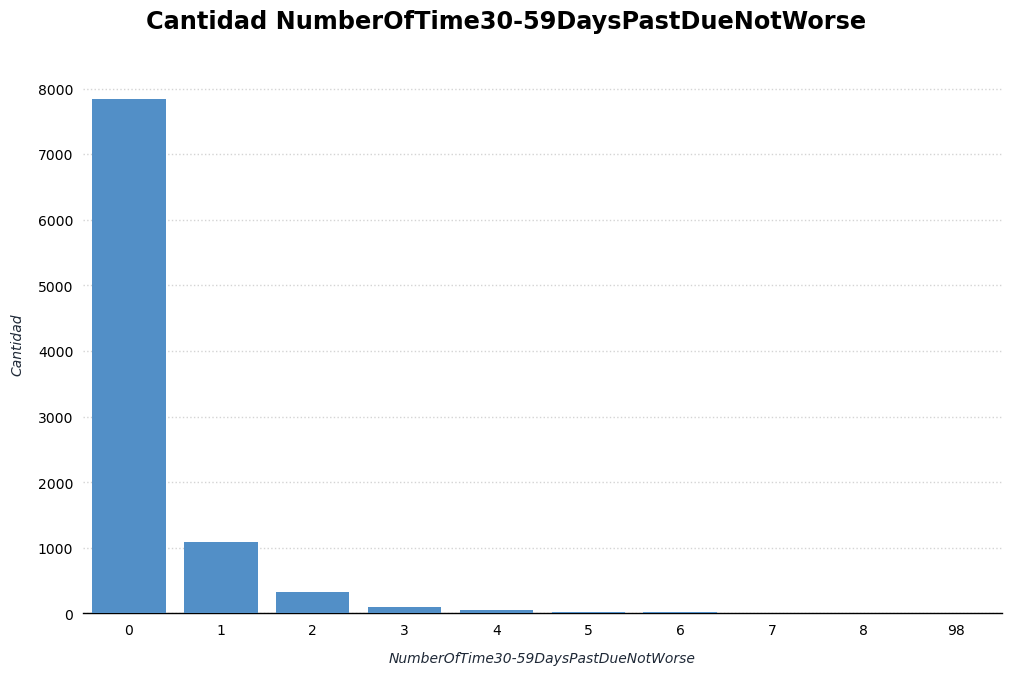

In [230]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Cantidad NumberOfTime30-59DaysPastDueNotWorse", y=1.1)
sns.countplot(
	x="NumberOfTime30-59DaysPastDueNotWorse",
	data=df_train,
	zorder=3,
	ax=ax
)
ax.set_xlabel("NumberOfTime30-59DaysPastDueNotWorse", fontstyle="italic")
ax.set_ylabel("Cantidad", fontstyle="italic")
ax.grid(axis="y")
ax.spines[["left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
plt.show()

In [231]:
df_train.replace(to_replace={
	"NumberOfTime30-59DaysPastDueNotWorse": {98: -1}
}, inplace=True).head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RELoanBin
2031,0,0.039187,61,0,0.269356,3073.0,7,0,2,0,0.0,Medium
10352,0,0.919317,41,0,0.162696,3945.0,3,0,0,0,0.0,None
497,0,0.253718,49,0,0.247302,13250.0,19,0,2,0,0.0,Medium
10341,0,0.249462,26,0,0.882353,764.0,4,0,0,0,0.0,None
4043,0,0.224520,76,0,0.462710,3150.0,6,0,1,0,0.0,Low


In [232]:
df_train["PD30-59Bin"] = pd.cut(
	x=df_train["NumberOfTime30-59DaysPastDueNotWorse"],
	bins=[-np.inf, -1, 0, 1, 3, np.inf],
	labels=["unknown", "No deliquency", "Low risk", "Medium risk", "High risk"],
	include_lowest=True
)

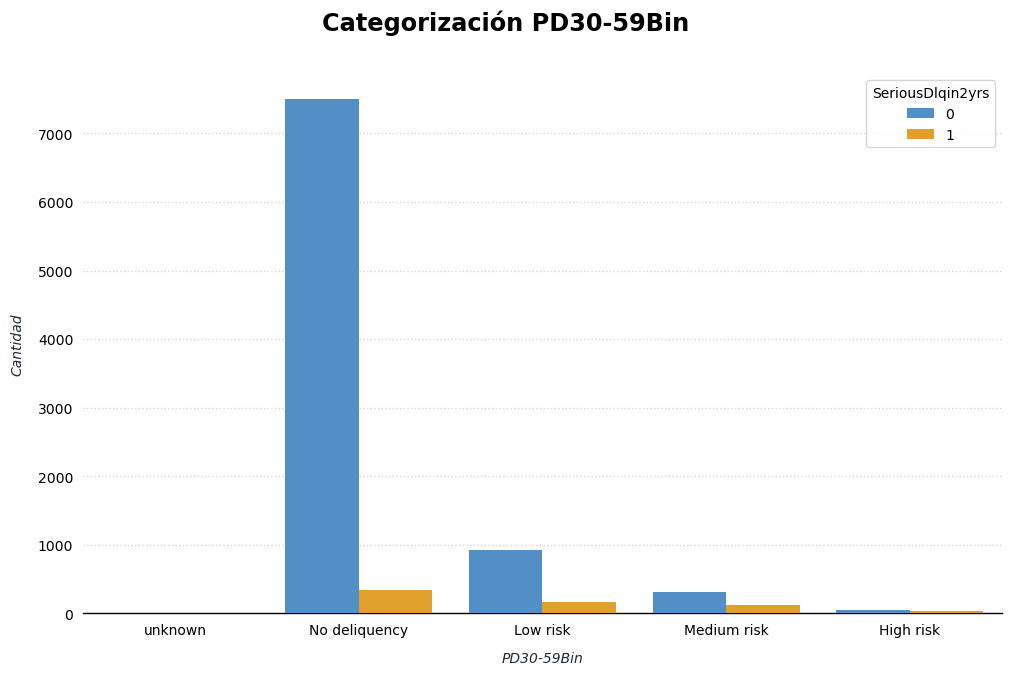

In [233]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Categorización PD30-59Bin", y=1.1)
sns.countplot(
	x="PD30-59Bin",
	data=df_train,
	hue=target,
	zorder=3,
	ax=ax
)
ax.set_xlabel("PD30-59Bin", fontstyle="italic")
ax.set_ylabel("Cantidad", fontstyle="italic")
ax.grid(axis="y")
ax.spines[["left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
plt.show()

In [234]:
df_test.replace(to_replace={
	"NumberOfTime30-59DaysPastDueNotWorse": {98: -1}
}, inplace=True).head()

df_test["PD30-59Bin"] = pd.cut(
	x=df_test["NumberOfTime30-59DaysPastDueNotWorse"],
	bins=[-np.inf, -1, 0, 1, 3, np.inf],
	labels=["unknown", "No deliquency", "Low risk", "Medium risk", "High risk"],
	include_lowest=True
)

#### NumberOfTime60-89DaysPastDueNotWorse

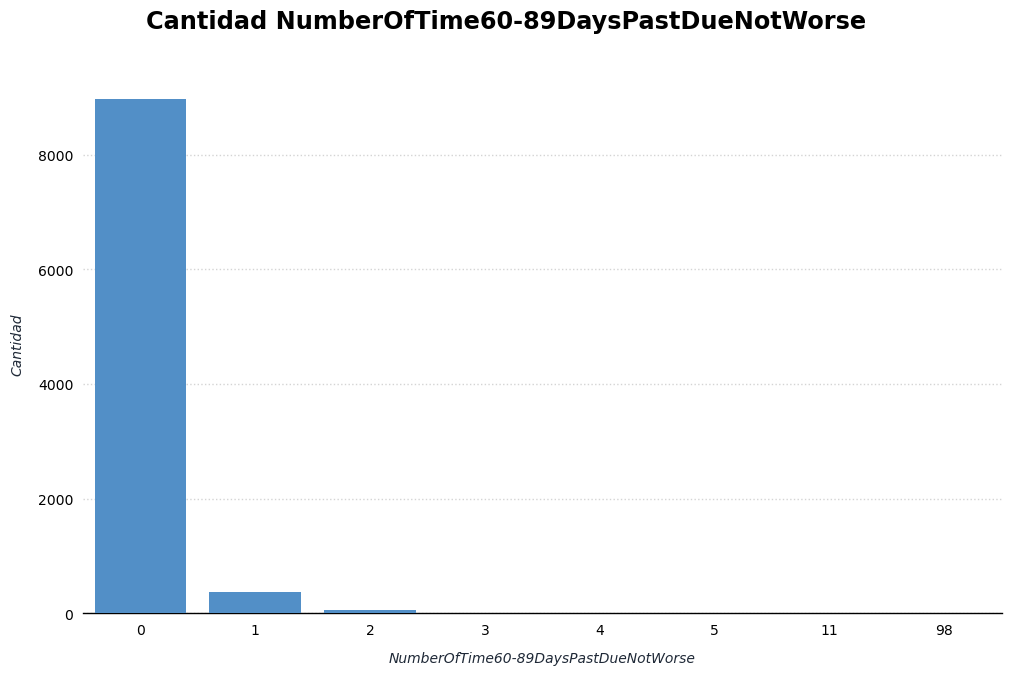

In [235]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Cantidad NumberOfTime60-89DaysPastDueNotWorse", y=1.1)
sns.countplot(
	x="NumberOfTime60-89DaysPastDueNotWorse",
	data=df_train,
	zorder=3,
	ax=ax
)
ax.set_xlabel("NumberOfTime60-89DaysPastDueNotWorse", fontstyle="italic")
ax.set_ylabel("Cantidad", fontstyle="italic")
ax.grid(axis="y")
ax.spines[["left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
plt.show()

In [236]:
df_train.replace(to_replace={
	"NumberOfTime60-89DaysPastDueNotWorse": {98: -1}
}, inplace=True).head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RELoanBin,PD30-59Bin
2031,0,0.039187,61,0,0.269356,3073.0,7,0,2,0,0.0,Medium,No deliquency
10352,0,0.919317,41,0,0.162696,3945.0,3,0,0,0,0.0,None,No deliquency
497,0,0.253718,49,0,0.247302,13250.0,19,0,2,0,0.0,Medium,No deliquency
10341,0,0.249462,26,0,0.882353,764.0,4,0,0,0,0.0,None,No deliquency
4043,0,0.224520,76,0,0.462710,3150.0,6,0,1,0,0.0,Low,No deliquency


In [237]:
df_train["PD60-89Bin"] = pd.cut(
	x=df_train["NumberOfTime60-89DaysPastDueNotWorse"],
	bins=[-np.inf, -1, 0, 1, 3, np.inf],
	labels=["unknown", "No deliquency", "Low risk", "Medium risk", "High risk"],
	include_lowest=True
)

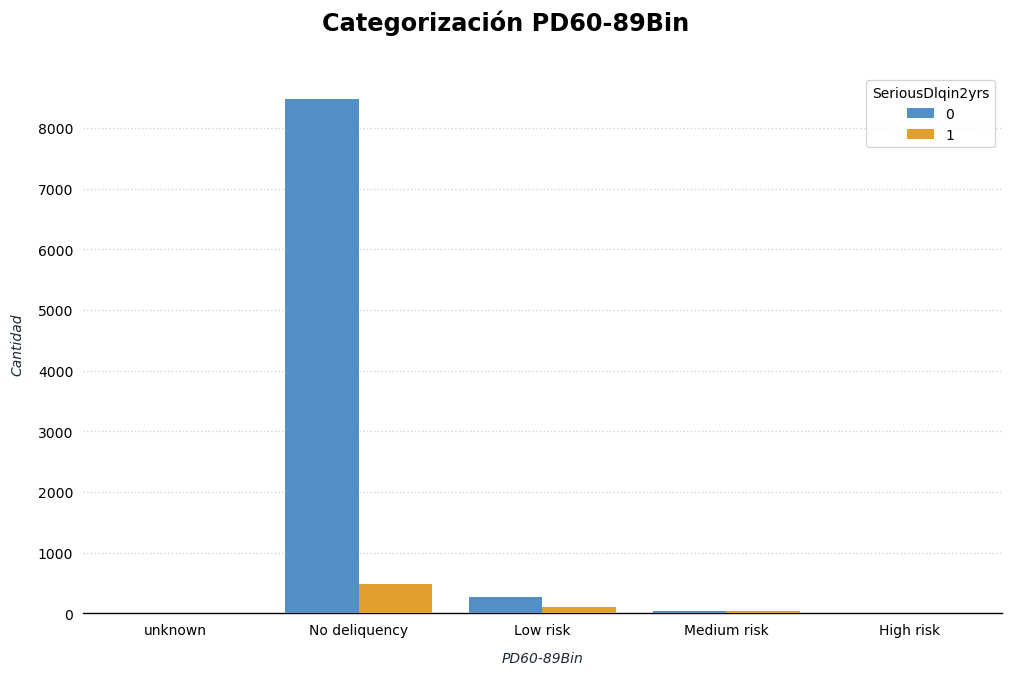

In [238]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Categorización PD60-89Bin", y=1.1)
sns.countplot(
	x="PD60-89Bin",
	data=df_train,
	hue=target,
	zorder=3,
	ax=ax
)
ax.set_xlabel("PD60-89Bin", fontstyle="italic")
ax.set_ylabel("Cantidad", fontstyle="italic")
ax.grid(axis="y")
ax.spines[["left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
plt.show()

In [239]:
df_test.replace(to_replace={
	"NumberOfTime60-89DaysPastDueNotWorse": {98: -1}
}, inplace=True).head()

df_test["PD60-89Bin"] = pd.cut(
	x=df_test["NumberOfTime60-89DaysPastDueNotWorse"],
	bins=[-np.inf, -1, 0, 1, 3, np.inf],
	labels=["unknown", "No deliquency", "Low risk", "Medium risk", "High risk"],
	include_lowest=True
)

#### NumberOfTimes90DaysLate

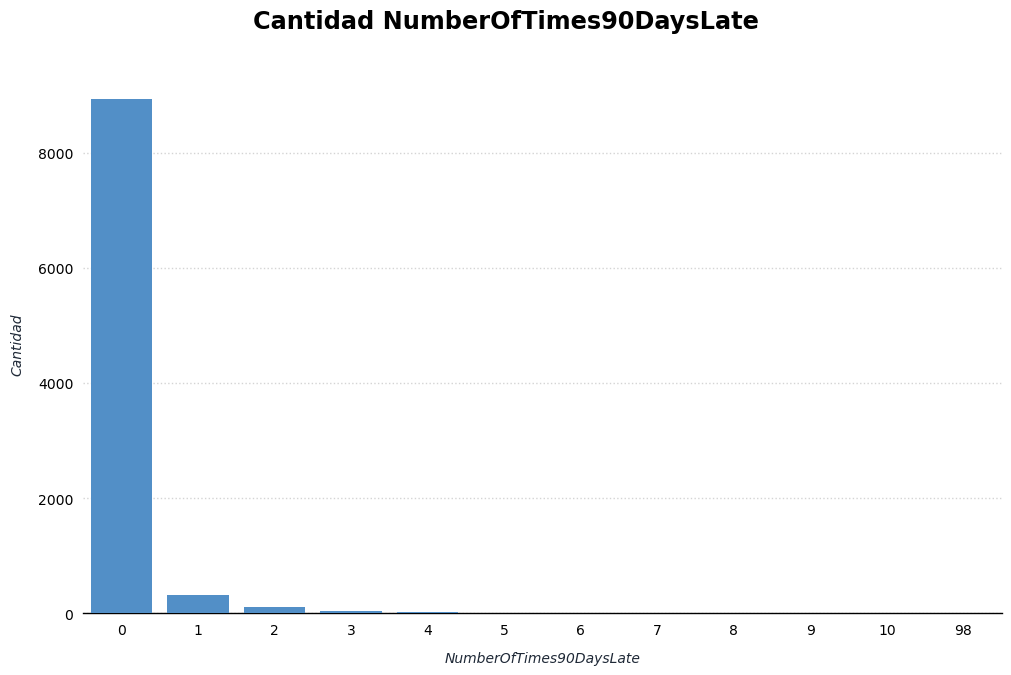

In [240]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Cantidad NumberOfTimes90DaysLate", y=1.1)
sns.countplot(
	x="NumberOfTimes90DaysLate",
	data=df_train,
	zorder=3,
	ax=ax
)
ax.set_xlabel("NumberOfTimes90DaysLate", fontstyle="italic")
ax.set_ylabel("Cantidad", fontstyle="italic")
ax.grid(axis="y")
ax.spines[["left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
plt.show()

In [241]:
df_train.replace(to_replace={
	"NumberOfTimes90DaysLate": {98: -1}
}, inplace=True).head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RELoanBin,PD30-59Bin,PD60-89Bin
2031,0,0.039187,61,0,0.269356,3073.0,7,0,2,0,0.0,Medium,No deliquency,No deliquency
10352,0,0.919317,41,0,0.162696,3945.0,3,0,0,0,0.0,None,No deliquency,No deliquency
497,0,0.253718,49,0,0.247302,13250.0,19,0,2,0,0.0,Medium,No deliquency,No deliquency
10341,0,0.249462,26,0,0.882353,764.0,4,0,0,0,0.0,None,No deliquency,No deliquency
4043,0,0.224520,76,0,0.462710,3150.0,6,0,1,0,0.0,Low,No deliquency,No deliquency


In [242]:
df_train["PD90Bin"] = pd.cut(
	x=df_train["NumberOfTimes90DaysLate"],
	bins=[-np.inf, -1, 0, 1, 3, np.inf],
	labels=["unknown", "No deliquency", "Low risk", "Medium risk", "High risk"],
	include_lowest=True
)

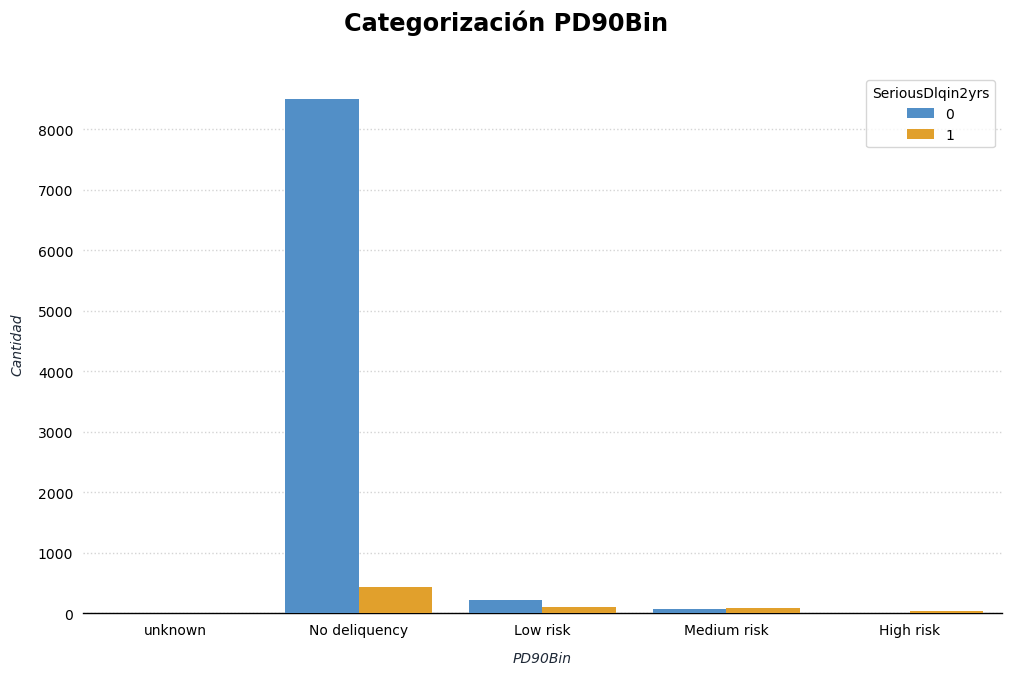

In [243]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Categorización PD90Bin", y=1.1)
sns.countplot(
	x="PD90Bin",
	data=df_train,
	hue=target,
	zorder=3,
	ax=ax
)
ax.set_xlabel("PD90Bin", fontstyle="italic")
ax.set_ylabel("Cantidad", fontstyle="italic")
ax.grid(axis="y")
ax.spines[["left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
plt.show()

In [244]:
df_test.replace(to_replace={
	"NumberOfTimes90DaysLate": {98: -1}
}, inplace=True).head()


df_test["PD90Bin"] = pd.cut(
	x=df_test["NumberOfTimes90DaysLate"],
	bins=[-np.inf, -1, 0, 1, 3, np.inf],
	labels=["unknown", "No deliquency", "Low risk", "Medium risk", "High risk"],
	include_lowest=True
)

#### NumberDependents

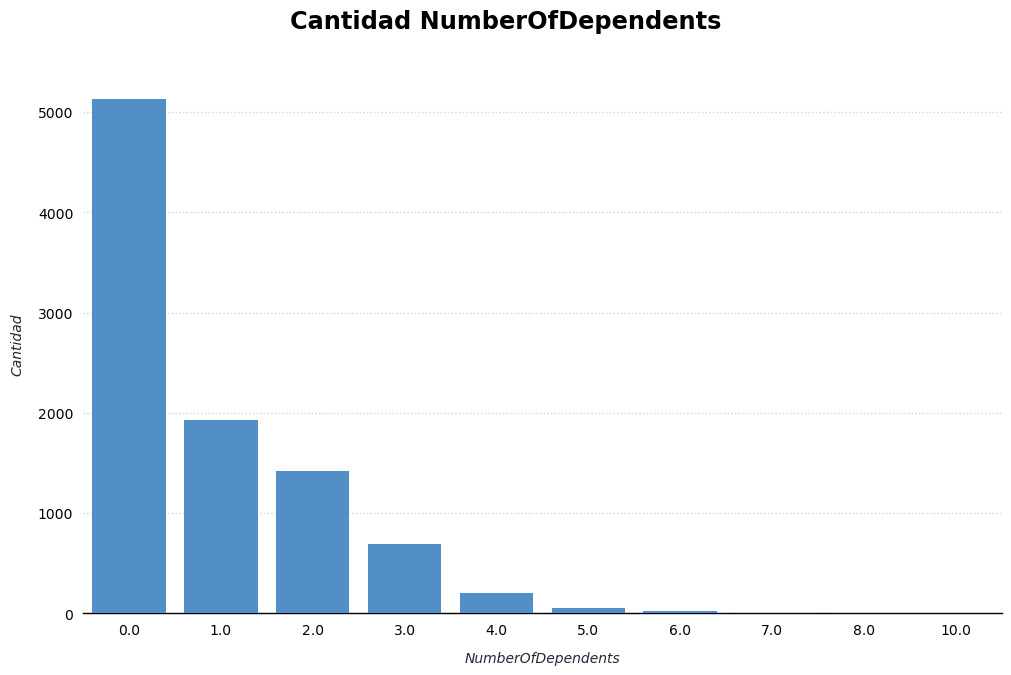

In [245]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Cantidad NumberOfDependents", y=1.1)
sns.countplot(
	x="NumberOfDependents",
	data=df_train,
	zorder=3,
	ax=ax
)
ax.set_xlabel("NumberOfDependents", fontstyle="italic")
ax.set_ylabel("Cantidad", fontstyle="italic")
ax.grid(axis="y")
ax.spines[["left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
plt.show()

In [246]:
df_train["DependentsBin"] = pd.cut(
	x=df_train["NumberOfDependents"],
	bins=[-np.inf, 0, 2, 4, np.inf],
	labels=["No dependents", "Low", "Medium", "High"],
	include_lowest=True
)

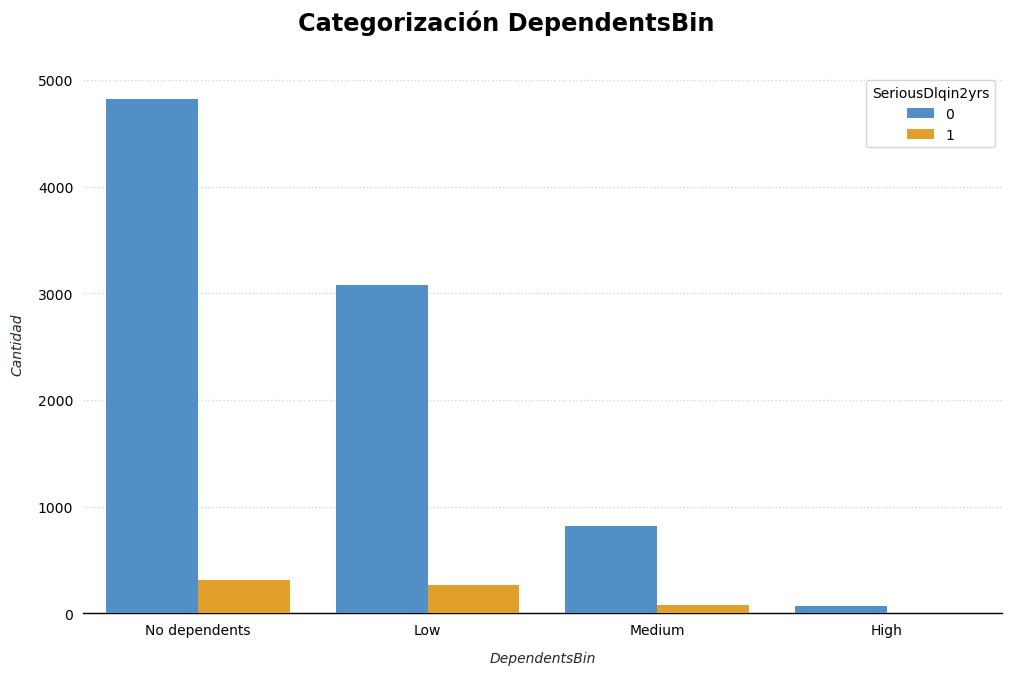

In [247]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Categorización DependentsBin", y=1.1)
sns.countplot(
	x="DependentsBin",
	data=df_train,
	hue=target,
	zorder=3,
	ax=ax
)
ax.set_xlabel("DependentsBin", fontstyle="italic")
ax.set_ylabel("Cantidad", fontstyle="italic")
ax.grid(axis="y")
ax.spines[["left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1)
plt.show()

In [248]:
df_test["DependentsBin"] = pd.cut(
	x=df_test["NumberOfDependents"],
	bins=[-np.inf, 0, 2, 4, np.inf],
	labels=["No dependents", "Low", "Medium", "High"],
	include_lowest=True
)

Eliminamos las columnas que ya no necesitamos.

In [251]:
categorical_features_raw = [
	"NumberRealEstateLoansOrLines",
	"NumberOfDependents",
	"NumberOfTime30-59DaysPastDueNotWorse",
	"NumberOfTime60-89DaysPastDueNotWorse",
	"NumberOfTimes90DaysLate"
]
# df_train.drop(columns=categorical_features_raw, inplace=True)

### Feature Selections

In [252]:
categorical_features_bin = [
	"RELoanBin",
	"PD30-59Bin",
	"PD60-89Bin",
	"PD90Bin",
	"DependentsBin"
]

numerical_features = [
	"RevolvingUtilizationOfUnsecuredLines",
	"age",
	"DebtRatio",
	"MonthlyIncome",
	"NumberOfOpenCreditLinesAndLoans"
]

##### `Filter`
###### `Pearson`, `Spearman`, `Kendall`

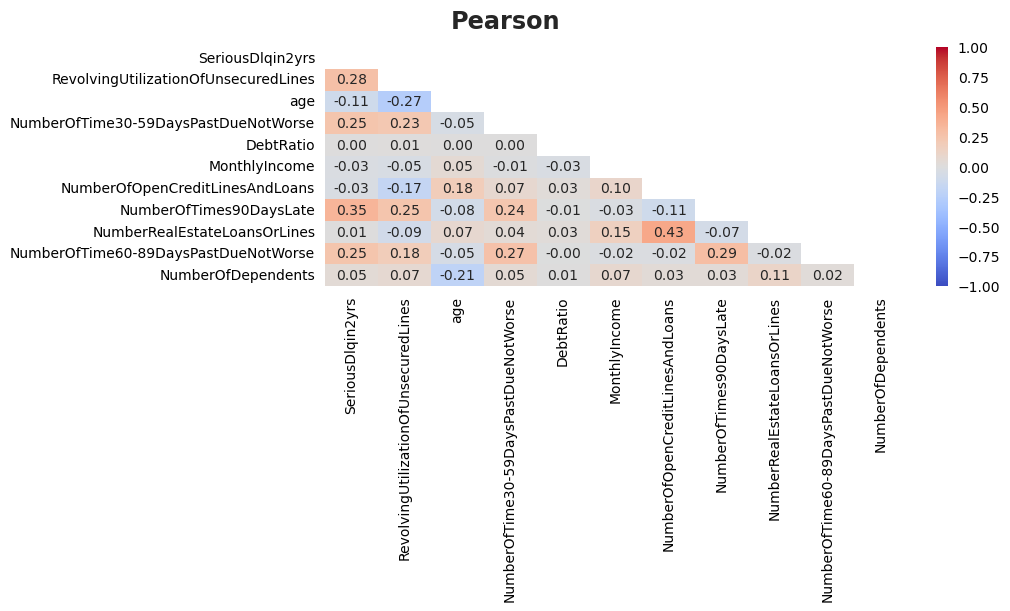

In [253]:
columns = df_train.select_dtypes("number").columns
correlations = df_train[columns].corr()
mask = np.triu(np.ones_like(correlations, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
fig.suptitle(f"Pearson",
			 color="#262626")
sns.heatmap(data=correlations,
			mask=mask,
			annot=True,
			cmap="coolwarm",
			fmt=".2f",
			center=0,
			linewidths=0,
			vmax=1,
			vmin=-1,
			ax=ax)
ax.set_xticks(ax.get_xticks(), labels=correlations.columns, rotation=90)
ax.set_yticks(ax.get_yticks(), labels=correlations.columns)
ax.grid(False)
plt.show()

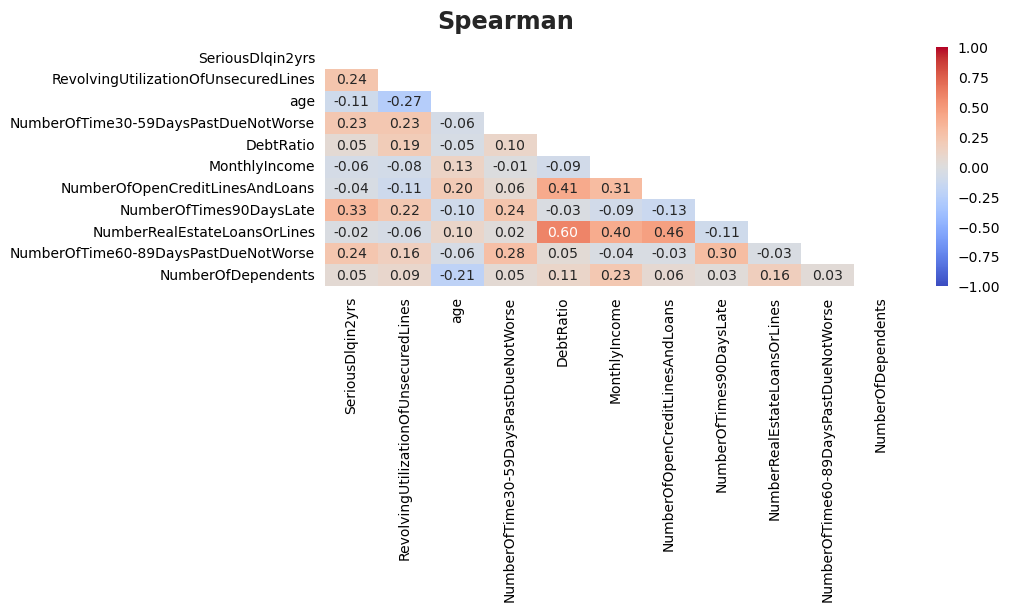

In [254]:
columns = df_train.select_dtypes("number").columns
correlations = df_train[columns].corr(method="spearman")
mask = np.triu(np.ones_like(correlations, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
fig.suptitle(f"Spearman",
			 color="#262626")
sns.heatmap(data=correlations,
			mask=mask,
			annot=True,
			cmap="coolwarm",
			fmt=".2f",
			center=0,
			linewidths=0,
			vmax=1,
			vmin=-1,
			ax=ax)
ax.set_xticks(ax.get_xticks(), labels=correlations.columns, rotation=90)
ax.set_yticks(ax.get_yticks(), labels=correlations.columns)
ax.grid(False)
plt.show()

Al ser la variable objetivo categórica, deberíamos utilizar `ANOVA`, $\chi^2$ y `Mutual Information`.

###### `Mutual Information`

In [259]:
target = "SeriousDlqin2yrs"

print("MUTUAL INFORMATION")
print("="*65)
for column in categorical_features_raw:
	mutual_information = mutual_info_score(
		df_train[column],
		df_train[target]
	)

	print(f"{column} - {target}: {mutual_information:.5f}")

MUTUAL INFORMATION
NumberRealEstateLoansOrLines - SeriousDlqin2yrs: 0.00302
NumberOfDependents - SeriousDlqin2yrs: 0.00134
NumberOfTime30-59DaysPastDueNotWorse - SeriousDlqin2yrs: 0.02432
NumberOfTime60-89DaysPastDueNotWorse - SeriousDlqin2yrs: 0.02071
NumberOfTimes90DaysLate - SeriousDlqin2yrs: 0.03639


Por lo que se puede ver, hay relación entre las features categóricas y nuestra variable objetivo `SeriousDlqin2yrs` si tomamos en cuenta el nivel de significancia 0.05.

###### `ANOVA`

In [ ]:
df_train_encoded = df_train.copy()

In [291]:
categories = [
	["None", "Low", "Medium", "High"],
	["unknown", "No deliquency", "Low risk", "Medium risk", "High risk"],
	["unknown", "No deliquency", "Low risk", "Medium risk", "High risk"],
	["unknown", "No deliquency", "Low risk", "Medium risk", "High risk"],
	["No dependents", "Low", "Medium", "High"],
]

categorical_features = [
	"RELoanBin",
	"PD30-59Bin",
	"PD60-89Bin",
	"PD90Bin",
	"DependentsBin"
]

ordinal_encoder = OrdinalEncoder(categories=categories, dtype=int)
ordinal_encoder.set_output(transform="pandas")
df_train_encoded[categorical_features] = ordinal_encoder.fit_transform(
	df_train[categorical_features]
)
df_train_encoded.sample(4)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RELoanBin,PD30-59Bin,PD60-89Bin,PD90Bin,DependentsBin
3470,0,0.542512,36,0,1.630842,4000.0,24,0,3,0,0.0,2,1,1,1,0
9581,0,0.312125,50,1,0.588246,5750.0,11,0,1,0,0.0,1,2,1,1,0
6677,0,0.233741,60,0,0.770857,2600.0,15,0,2,0,0.0,2,1,1,1,0
1449,0,0.750047,27,0,0.187604,3613.0,7,0,0,0,0.0,0,1,1,1,0


In [293]:
df_test_encoded = df_test.copy()

In [294]:
ordinal_encoder = OrdinalEncoder(categories=categories, dtype=int)
ordinal_encoder.set_output(transform="pandas")
df_test_encoded[categorical_features] = ordinal_encoder.fit_transform(
	df_train[categorical_features]
)
df_test_encoded.sample(4)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RELoanBin,PD30-59Bin,PD60-89Bin,PD90Bin,DependentsBin
7611,0,0.006823,57,0,0.294769,4874.0,15,0,1,0,0.0,NaN,NaN,NaN,NaN,NaN
4133,0,0.470881,39,0,0.220708,35000.0,8,0,2,0,2.0,NaN,NaN,NaN,NaN,NaN
7970,0,1.000000,25,0,0.000000,600.0,1,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN
2128,0,0.055888,27,0,0.367554,2064.0,4,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN


In [295]:
for column in categorical_features_raw:
	print(column)
	print("="*50)
	columns = [column] + [target]
	f_statistics, p_value = stats.f_oneway(df_train[columns])
	print("\t- f-estadístico:", f_statistics)
	print("\t- p-value:", p_value)
	print()

NumberRealEstateLoansOrLines
	- f-estadístico: 6709.800526855756
	- p-value: 0.0

NumberOfDependents
	- f-estadístico: 4194.213910391764
	- p-value: 0.0

NumberOfTime30-59DaysPastDueNotWorse
	- f-estadístico: 601.9581130395529
	- p-value: 6.96475725377441e-131

NumberOfTime60-89DaysPastDueNotWorse
	- f-estadístico: 1.2056064940398241
	- p-value: 0.2722179796494629

NumberOfTimes90DaysLate
	- f-estadístico: 12.953342528847804
	- p-value: 0.00032016704598861596



###### **SelectKBest**
**`ANOVA`**

In [296]:
f_classif(df_train[categorical_features_raw], df_train[target])

(array([3.14679481e-01, 2.01252855e+01, 6.19410813e+02, 6.05134967e+02,
        1.30272716e+03]),
 array([5.74836065e-001, 7.33882974e-006, 1.73836390e-132, 1.43289046e-129,
        2.30144252e-267]))

Elegimos las tres mejores features que correlacionen con el target.

In [297]:
select_kbest = SelectKBest(f_classif, k=5)
#select_kbest.set_output(transform="pandas")
data = select_kbest.fit_transform(
	df_train[categorical_features_raw],
	df_train[target]
)

In [298]:
pd.DataFrame(
	data=[
		pd.Series(select_kbest.pvalues_, index=categorical_features_raw),
		pd.Series(select_kbest.scores_, index=categorical_features_raw)
	],
	index=["p_values", "scores"]
).T.sort_values(by="p_values", ascending=True)

,p_values,scores
NumberOfTimes90DaysLate,2.301443e-267,1302.727155
NumberOfTime30-59DaysPastDueNotWorse,1.738364e-132,619.410813
NumberOfTime60-89DaysPastDueNotWorse,1.432890e-129,605.134967
NumberOfDependents,7.338830e-06,20.125285
NumberRealEstateLoansOrLines,5.748361e-01,0.314679


Features seleccionadas

In [266]:
pd.DataFrame(
	data=data,
	columns=select_kbest.get_feature_names_out()
).head()

,NumberRealEstateLoansOrLines,NumberOfDependents,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
0,2.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,2.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0


**`Chi²`**

In [267]:
select_kbest = SelectKBest(chi2, k=5)
#select_kbest.set_output(transform="pandas")
data = select_kbest.fit_transform(
	df_train[numerical_features],
	df_train[target]
)

In [268]:
pd.DataFrame(
	data=[
		pd.Series(select_kbest.pvalues_, index=numerical_features),
		pd.Series(select_kbest.scores_, index=numerical_features)
	],
	index=["p_values", "scores"]
).T.sort_values(by="p_values", ascending=True)

,p_values,scores
MonthlyIncome,0.000000e+00,143985.906990
age,4.579427e-96,432.527364
RevolvingUtilizationOfUnsecuredLines,1.662479e-65,292.183690
NumberOfOpenCreditLinesAndLoans,1.725660e-08,31.781075
DebtRatio,9.738641e-01,0.001073


###### **U de Mann-Whitney**

**DebtRatio**

In [ ]:
group0 = df_train[df_train["SeriousDlqin2yrs"] == 0]["DebtRatio"]
group1 = df_train[df_train["SeriousDlqin2yrs"] == 1]["DebtRatio"]

f_statistics, p_value = stats.mannwhitneyu(
	group0,
	group1,
	alternative="two-sided"
)

print(f"Estadístico U: {f_statistics}")
print(f"p-value: {p_value}")

Estadístico U: 2593400.5
p-value: 1.735414495731165e-06


La variable `DebtRatio` tiene una fuerte relación con nuestro target.

**MonthlyIncome**

In [270]:
group0 = df_train[df_train["SeriousDlqin2yrs"] == 0]["MonthlyIncome"]
group1 = df_train[df_train["SeriousDlqin2yrs"] == 1]["MonthlyIncome"]

f_statistics, p_value = stats.mannwhitneyu(
	group0,
	group1,
	alternative="two-sided"
)

print(f"Estadístico U: {f_statistics}")
print(f"p-value: {p_value}")

Estadístico U: 3344578.5
p-value: 3.022971072848152e-10


La variable `MonthlyIncome` tiene una fuerte relación con nuestro target.

**age**

In [271]:
group0 = df_train[df_train["SeriousDlqin2yrs"] == 0]["age"]
group1 = df_train[df_train["SeriousDlqin2yrs"] == 1]["age"]

f_statistics, p_value = stats.mannwhitneyu(
	group0,
	group1,
	alternative="two-sided"
)

print(f"Estadístico U: {f_statistics}")
print(f"p-value: {p_value}")

Estadístico U: 3619475.0
p-value: 4.0079421314265056e-25


La variable `age` tiene una fuerte relación con nuestro target.

**NumberOfOpenCreditLinesAndLoan**

In [272]:
group0 = df_train[df_train["SeriousDlqin2yrs"] == 0]["NumberOfOpenCreditLinesAndLoans"]
group1 = df_train[df_train["SeriousDlqin2yrs"] == 1]["NumberOfOpenCreditLinesAndLoans"]

f_statistics, p_value = stats.mannwhitneyu(
	group0,
	group1,
	alternative="two-sided"
)

print(f"Estadístico U: {f_statistics}")
print(f"p-value: {p_value}")

Estadístico U: 3196946.5
p-value: 3.63652007964641e-05


La variable `NumberOfOpenCreditLinesAndLoans` tiene una fuerte relación con nuestro target.

**RevolvingUtilizationOfUnsecuredLines**

In [273]:
group0 = df_train[df_train["SeriousDlqin2yrs"] == 0]["RevolvingUtilizationOfUnsecuredLines"]
group1 = df_train[df_train["SeriousDlqin2yrs"] == 1]["RevolvingUtilizationOfUnsecuredLines"]

f_statistics, p_value = stats.mannwhitneyu(
	group0,
	group1,
	alternative="two-sided"
)

print(f"Estadístico U: {f_statistics}")
print(f"p-value: {p_value}")

Estadístico U: 1315837.5
p-value: 1.8364077512945064e-123


La variable `RevolvingUtilizationOfUnsecuredLines` tiene una fuerte relación con nuestro target.

#### `Intrinsic`
##### `SelectFromModel`

Utilizamos un `RandomForestClassifier` para realizar una selección de los mejores atributos.

In [299]:
random_forest = RandomForestClassifier(
	class_weight="balanced",
	n_jobs=-1,
	random_state=42
)

random_forest.fit(
	df_train_encoded.drop(columns=categorical_features_raw + [target]),
	df_train_encoded[target]
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Graficamos como el modelo ha capturado la importancia de cada atributo de nuestros datos.

In [300]:
feature_importances = pd.DataFrame(
	data=random_forest.feature_importances_,
	index=random_forest.feature_names_in_,
	columns=["importance"]
).sort_values(by="importance", ascending=False)
feature_importances.head()

,importance
RevolvingUtilizationOfUnsecuredLines,0.279200
DebtRatio,0.131172
MonthlyIncome,0.123102
age,0.119738
NumberOfOpenCreditLinesAndLoans,0.086874


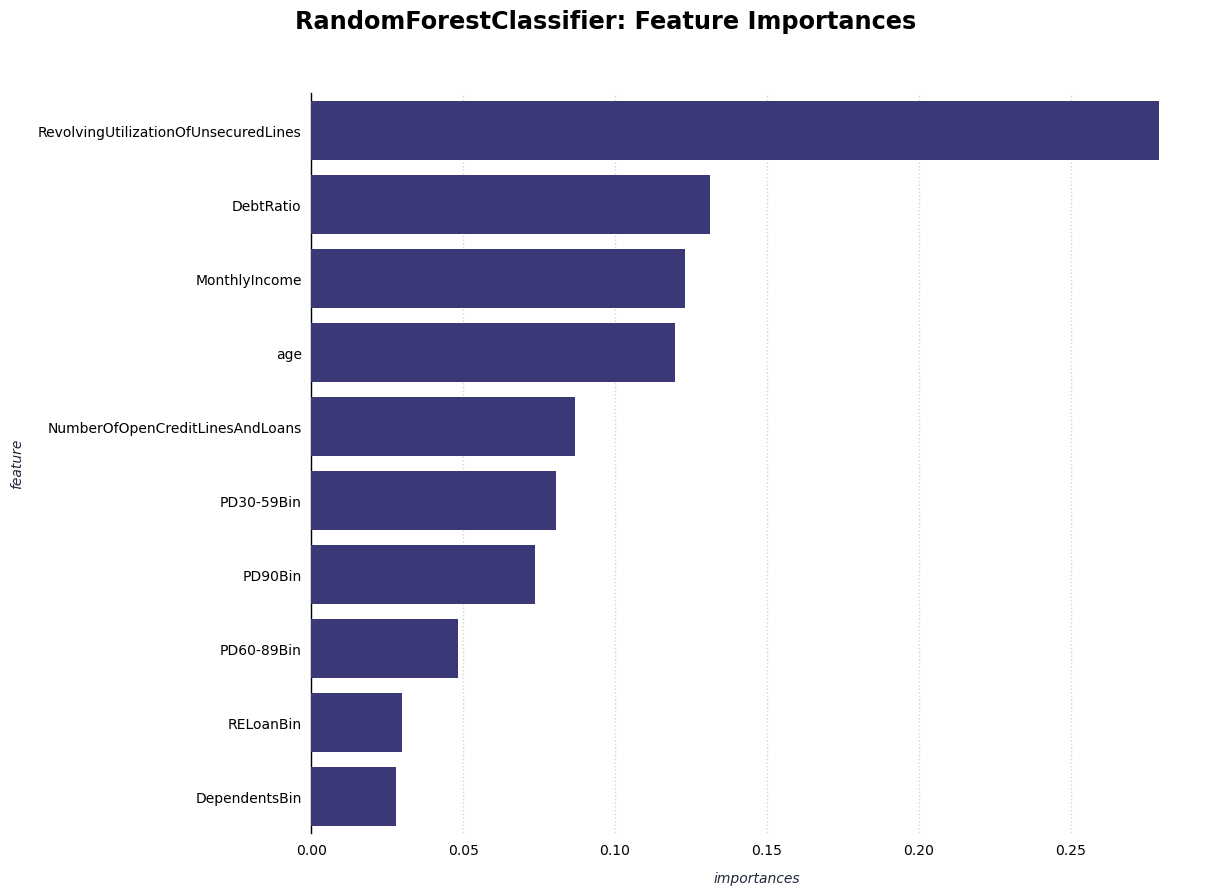

In [301]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle(f"RandomForestClassifier: Feature Importances", y=1.1)
sns.barplot(
	x=feature_importances.importance,
	y=feature_importances.index,
	data=feature_importances,
	color="#312E81",
	zorder=3,
	ax=ax
)
ax.set_xlabel("importances", fontstyle="italic")
ax.set_ylabel("feature", fontstyle="italic")
ax.grid(axis="x")
ax.spines[["bottom"]].set_visible(False)
ax.spines["left"].set_linewidth(1)
plt.show()

Utilizamos `SelectFromModel` para elegir los atributos más significativos para nuestro modelo.

In [302]:
select_from_model = SelectFromModel(estimator=random_forest, threshold="median")
select_from_model.fit(
	df_train_encoded.drop(columns=categorical_features_raw + [target]),
	df_train_encoded[target]
)

,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",RandomForestC...ndom_state=42)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",'median'
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1
,"max_features max_features: int, callable, default=NoneThe maximum number of features to select.- If an integer, then it specifies the maximum number of features to allow.- If a callable, then it specifies how to calculate the maximum number of features allowed. The callable will receive `X` as input: `max_features(X)`.- If `None`, then all features are kept.To only select based on ``max_features``, set ``threshold=-np.inf``... versionadded:: 0.20.. versionchanged:: 1.1 `max_features` accepts a callable.",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a ``coef_``attribute or ``feature_importances_`` attribute of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each o

In [303]:
pd.DataFrame(
	select_from_model.transform(
		df_train_encoded.drop(columns=categorical_features_raw + [target])
	),
	columns=select_from_model.get_feature_names_out()
).sample(10)

,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans
996,0.371730,57.0,0.489450,10805.0,12.0
4770,0.673663,41.0,0.431755,14000.0,16.0
6435,1.020979,31.0,0.160473,6000.0,4.0
7306,0.650171,35.0,0.587011,1200.0,4.0
1524,0.978962,66.0,0.321805,4741.0,5.0
2024,0.051432,51.0,0.290280,8384.0,12.0
2295,0.563830,25.0,0.105263,3400.0,4.0
8837,1.034361,45.0,0.430228,7846.0,12.0
4364,0.055210,60.0,1.126873,1000.0,9.0
1680,0.554803,75.0,2.629630,701.0,5.0


Hemos utilizado un ***RandomForestClassifier*** y aplicando ***SelectFromModel*** nos quedamos con cinco features: `age`, `DebtRatio`, `MonthlyIncome`, `RevolvingUtilizationOfUnsecuredLines` y `NumberOfOpenCreditLinesAndLoans`.

#### **Wrapper**

##### `RFE` (Recursive Feature Elimination)

Implementamos la técnica de `RecursiveFeatureElimination` para conseguir los mejores 6 atributos.

In [304]:
rfe = RFE(
	estimator=RandomForestClassifier(
		class_weight="balanced",
		n_jobs=-1,
		random_state=42
	),
	n_features_to_select=6,
	step=1,
)

columns = df_train_encoded.drop(
	columns=categorical_features_raw + [target]
).columns
rfe.fit(X=df_train_encoded[columns], y=df_train_encoded[target])

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",6
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [305]:
pd.DataFrame(
	rfe.ranking_,
	columns=["ranking"],
	index=columns
).sort_values("ranking").head(6)

,ranking
RevolvingUtilizationOfUnsecuredLines,1
age,1
DebtRatio,1
MonthlyIncome,1
NumberOfOpenCreditLinesAndLoans,1
PD90Bin,1


##### `SFS` (Sequential Feature Selection)

In [306]:
sfs = SequentialFeatureSelector(
	estimator=RandomForestClassifier(
		class_weight="balanced",
		n_jobs=-1,
		random_state=42
	),
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	n_features_to_select=6,
	scoring="balanced_accuracy",
	n_jobs=-1
)

columns = df_train_encoded.drop(
	columns=categorical_features_raw + [target]
).columns
sfs.fit(X=df_train_encoded[columns], y=df_train_encoded[target])

,estimator estimator: estimator instanceAn unfitted estimator.,RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",6
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'balanced_accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [307]:
pd.Series(sfs.get_feature_names_out(), name="ranking")

0    RevolvingUtilizationOfUnsecuredLines
1                               RELoanBin
2                              PD30-59Bin
3                              PD60-89Bin
4                                 PD90Bin
5                           DependentsBin
Name: ranking, dtype: str

#### Hard Voting

In [308]:
mi = [
	"NumberRealEstateLoansOrLines",
	"NumberOfDependents",
	"NumberOfTime30-59DaysPastDueNotWorse",
	"NumberOfTime60-89DaysPastDueNotWorse",
	"NumberOfTimes90DaysLate"
]

select_kbest_anova = [
	"NumberOfTimes90DaysLate",
	"NumberOfTime30-59DaysPastDueNotWorse",
	"NumberOfTime60-89DaysPastDueNotWorse",
	"NumberOfDependents",
	"NumberRealEstateLoansOrLines"
]

select_kbest_chi2 = [
	"MonthlyIncome",
	"age",
	"RevolvingUtilizationOfUnsecuredLines",
	"NumberOfOpenCreditLinesAndLoans",
	"DebtRatio"
]

u_mann_whitney = [
	"DebtRatio",
	"MonthlyIncome",
	"age",
	"NumberOfOpenCreditLinesAndLoans",
	"RevolvingUtilizationOfUnsecuredLines",
]

select_fmodel = [
	"RevolvingUtilizationOfUnsecuredLines",
	"DebtRatio",
	"MonthlyIncome",
	"age",
	"NumberOfOpenCreditLinesAndLoans"
]

rfe = [
	"RevolvingUtilizationOfUnsecuredLines",
	"age",
	"DebtRatio",
	"MonthlyIncome",
	"NumberOfOpenCreditLinesAndLoans",
	"PD90Bin"
]

sfs = [
	"RevolvingUtilizationOfUnsecuredLines",
	"RELoanBin",
	"PD30-59Bin",
	"PD60-89Bin",
	"PD90Bin",
	"DependentsBin"
]

all = mi + select_kbest_anova + select_kbest_chi2 + u_mann_whitney + select_fmodel + rfe + sfs
votes = Counter(all)

In [309]:
most_voted = pd.DataFrame(
	data=votes.values(),
	index=votes.keys(),
	columns=["votes"]
).sort_values(by=["votes"], ascending=False)
most_voted.iloc[:6, :]

,votes
RevolvingUtilizationOfUnsecuredLines,5
MonthlyIncome,4
age,4
NumberOfOpenCreditLinesAndLoans,4
DebtRatio,4
NumberOfTime30-59DaysPastDueNotWorse,2


## Machine Learning: Modelos

In [315]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [336]:
technique = [
	"mutual_information",
	"select_kbest_anova",
	"select_kbest_chi2",
	"u_mann_whitney",
	"select_fmodel",
	"rfe",
	"sfs"
]

feature_set = [
	mi,
	select_kbest_anova,
	select_kbest_chi2,
	u_mann_whitney,
	select_fmodel,
	rfe,
	sfs
]

#### `RandomForestClassifier`

In [313]:
random_forest = RandomForestClassifier(
	class_weight="balanced",
	n_jobs=-1,
	random_state=42
)

In [314]:
for key, value in zip(technique, feature_set):
	print(key.upper())
	print("="*60)
	results = cross_validate(
		estimator=random_forest,
		X=df_train_encoded[value],
		y=df_train_encoded[target],
		cv=KFold(n_splits=5, shuffle=True, random_state=42),
		scoring=["balanced_accuracy"],
		n_jobs=-1
	)

	random_forest.fit(
		df_train_encoded[value],
		df_train_encoded[target]
	)

	ba = np.mean(results["test_balanced_accuracy"])
	print(f"Train Recall: {ba:.2f}")

	predicts = random_forest.predict(df_test_encoded[value])
	print("\nTest: Classification Report")
	print(classification_report(df_test_encoded[target], predicts))

MUTUAL_INFORMATION
Train Recall: 0.65

Test: Classification Report
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2198
           1       0.23      0.48      0.31       166

    accuracy                           0.85      2364
   macro avg       0.59      0.68      0.61      2364
weighted avg       0.91      0.85      0.88      2364

SELECT_KBEST_ANOVA
Train Recall: 0.65

Test: Classification Report
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2198
           1       0.23      0.48      0.31       166

    accuracy                           0.85      2364
   macro avg       0.59      0.68      0.61      2364
weighted avg       0.91      0.85      0.87      2364

SELECT_KBEST_CHI2
Train Recall: 0.52

Test: Classification Report
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2198
           1       0.42      0.05    

Los mejores set de features son `Mutual Information` y `SelectKBest` con f_classif, con estos sets de features el modelo logra la mejo generalización.

#### `LightGBM`

In [316]:
light_gbm = LGBMClassifier(
	class_weight="balanced",
	n_jobs=-1,
	random_state=42,
	verbosity=-1
)

In [319]:
for key, value in zip(technique, feature_set):
	print(key.upper())
	print("="*60)
	results = cross_validate(
		estimator=light_gbm,
		X=df_train_encoded[value],
		y=df_train_encoded[target],
		cv=KFold(n_splits=5, shuffle=True, random_state=42),
		scoring=["balanced_accuracy"],
		n_jobs=-1
	)

	light_gbm.fit(
		df_train_encoded[value],
		df_train_encoded[target]
	)

	ba = np.mean(results["test_balanced_accuracy"])
	print(f"Train Recall: {ba:.2f}")

	predicts = light_gbm.predict(df_test_encoded[value])
	print("\nTest: Classification Report")
	print(classification_report(df_test_encoded[target], predicts))

MUTUAL_INFORMATION
Train Recall: 0.73

Test: Classification Report
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2198
           1       0.23      0.61      0.33       166

    accuracy                           0.83      2364
   macro avg       0.60      0.73      0.61      2364
weighted avg       0.91      0.83      0.86      2364

SELECT_KBEST_ANOVA
Train Recall: 0.73

Test: Classification Report
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2198
           1       0.23      0.61      0.33       166

    accuracy                           0.83      2364
   macro avg       0.60      0.73      0.61      2364
weighted avg       0.91      0.83      0.86      2364

SELECT_KBEST_CHI2
Train Recall: 0.67

Test: Classification Report
              precision    recall  f1-score   support

           0       0.96      0.83      0.89      2198
           1       0.20      0.57    

Los mejores set de features son `Mutual Information` y `SelectKBest` con f_classif, con estos sets de features el modelo logra la mejo generalización. El otro conjunto de features con el que se logra una buena performance es el que se logro con `RFE`.

#### `CatBoost`

In [320]:
from catboost import CatBoostClassifier

In [334]:
cat_boost = CatBoostClassifier(
	auto_class_weights="Balanced",
	random_state=42,
	verbose=False
)

In [335]:
for key, value in zip(technique, feature_set):
	print(key.upper())
	print("="*60)
	results = cross_validate(
		estimator=cat_boost,
		X=df_train_encoded[value],
		y=df_train_encoded[target],
		cv=KFold(n_splits=5, shuffle=True, random_state=42),
		scoring=["balanced_accuracy"],
		n_jobs=-1
	)

	cat_boost.fit(
		df_train_encoded[value],
		df_train_encoded[target]
	)

	ba = np.mean(results["test_balanced_accuracy"])
	print(f"Train Recall: {ba:.2f}")

	predicts = cat_boost.predict(df_test_encoded[value])
	print("\nTest: Classification Report")
	print(classification_report(df_test_encoded[target], predicts))

MUTUAL_INFORMATION
Train Recall: 0.73

Test: Classification Report
              precision    recall  f1-score   support

           0       0.97      0.85      0.90      2198
           1       0.23      0.60      0.33       166

    accuracy                           0.83      2364
   macro avg       0.60      0.72      0.62      2364
weighted avg       0.91      0.83      0.86      2364

SELECT_KBEST_ANOVA
Train Recall: 0.73

Test: Classification Report
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      2198
           1       0.23      0.59      0.33       166

    accuracy                           0.83      2364
   macro avg       0.60      0.72      0.62      2364
weighted avg       0.91      0.83      0.86      2364

SELECT_KBEST_CHI2
Train Recall: 0.68

Test: Classification Report
              precision    recall  f1-score   support

           0       0.96      0.84      0.90      2198
           1       0.20      0.54    

Los mejores set de features son `Mutual Information` y `SelectKBest` con f_classif, con estos sets de features el modelo logra la mejo generalización.

### Best Model

In [338]:
cat_boost = CatBoostClassifier(
	eval_metric="AUC",
	loss_function="Logloss",
	random_state=42,
	verbose=False
)

#### RandomizedSearchCV

In [356]:
params = {
	"iterations": [300, 600, 1000],
	"depth": [4, 6, 8, 10],
	"learning_rate": np.linspace(0.01, 0.2, 20),
	"l2_leaf_reg": np.linspace(1, 10, 10),
	"subsample": [0.6, 0.7, 0.8, 0.9, 1],
	"colsample_bylevel": [0.6, 0.8, 1],
	"min_data_in_leaf": [1, 5, 10, 20, 50],
	"bagging_temperature": np.linspace(0, 5, 20),
	"auto_class_weights": ["Balanced", "SqrtBalanced"]
}

random_search = RandomizedSearchCV(
	cat_boost,
	param_distributions=params,
	n_iter=80,
	scoring="balanced_accuracy",
	cv=5,
	n_jobs=-1,
	verbose=1,
	random_state=42
)

random_search.fit(df_train_encoded[feature_set[0]], df_train_encoded[target])

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass...verbose=False)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'auto_class_weights': ['Balanced', 'SqrtBalanced'], 'bagging_temperature': array([0. ..., 5. ]), 'colsample_bylevel': [0.6, 0.8, ...], 'depth': [4, 6, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-val

In [357]:
best_params = random_search.best_params_
best_params

{'subsample': 0.6,
 'min_data_in_leaf': 20,
 'learning_rate': np.float64(0.02),
 'l2_leaf_reg': np.float64(5.0),
 'iterations': 300,
 'depth': 6,
 'colsample_bylevel': 0.6,
 'bagging_temperature': np.float64(1.3157894736842104),
 'auto_class_weights': 'Balanced'}

In [358]:
cat_boost = CatBoostClassifier(
	**best_params,
	eval_metric="AUC",
	loss_function="Logloss",
	random_state=42,
	verbose=False
)

In [359]:
results = cross_validate(
	estimator=cat_boost,
	X=df_train_encoded[feature_set[0]],
	y=df_train_encoded[target],
	cv=KFold(n_splits=5, shuffle=True, random_state=42),
	scoring=["balanced_accuracy"],
	n_jobs=-1
)


cat_boost.fit(
	df_train_encoded[feature_set[0]],
	df_train_encoded[target]
)

ba = np.mean(results["test_balanced_accuracy"])
print(f"Train Recall: {ba:.2f}")

predicts = cat_boost.predict(df_test_encoded[feature_set[0]])
print("\nTest: Classification Report")
print(classification_report(df_test_encoded[target], predicts))

Train Recall: 0.74

Test: Classification Report
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      2198
           1       0.22      0.62      0.33       166

    accuracy                           0.82      2364
   macro avg       0.59      0.73      0.61      2364
weighted avg       0.91      0.82      0.86      2364



## EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.